# N_of_1_preprocesamiento

Este notebook prepara los datos personales de la autora (Xiaomi Smart Watch S4, export Mi Fitness)
para el estudio de validación n-of-1, en tres bloques.

El **bloque 1** explora la estructura cruda de los ficheros exportados. El **bloque 2** extrae,
resamplea y consolida las señales en una matriz temporal unificada, incorporando sueño, ejercicio y
un filtro de plausibilidad fisiológica de HR. El **bloque 3** normaliza HR por baseline circadiano
personal mediante un modelo Ornstein-Uhlenbeck ajustado por MCMC, documentando el proceso de diseño a
través de las iteraciones sucesivas del modelo. El **bloque 4** deriva una segunda normalización,
compatible con la escala de `StressLoad(t)`, a partir de una referencia de calma fisiológica
identificada empíricamente. El **bloque 5** replica las características de Camino B (WESAD) sobre
estos datos reales, con una corrección *gap-aware* para huecos de cobertura, y guarda el dataset final.

# 0. Imports y configuración de rutas

Librerías utilizadas a lo largo del notebook, y todas las rutas de entrada/salida centralizadas
aquí —tanto los datos crudos del export de Mi Fitness como los artefactos generados (ajuste MCMC del
baseline circadiano, dataset final procesado)—, leídas desde `MVA_config_rutas.json` para no
depender de rutas absolutas embebidas en el código.

In [1]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee

from formulario_utils import load_form_doses, load_form_ema

# --- Configuración y rutas ---
CONFIG_PATH = Path("MVA_config_rutas.json")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

# Datos crudos del export de Mi Fitness (Xiaomi Smart Watch S4)
RAW_DATA_DIR = Path(config["rutas"]["general"]["raw_data_dir_extended"])
RUTA_FITNESS_DATA = Path(config["rutas"]["general"]["mifitness_fitness_data"])
RUTA_SPORT_RECORD = Path(config["rutas"]["general"]["mifitness_sport_record"])

# Formulario de dosis reales (Google Forms) y dataset final procesado (salida del notebook)
XLSX_PATH = Path(config["rutas"]["general"]["formulario"])
RUTA_PROCESSED = Path(config["rutas"]["general"]["processed_data_extended"])

# Artefactos del ajuste MCMC del baseline circadiano (Sección 3), para no recalcular en cada ejecución
RUTA_ARTEFACTOS = Path(config["rutas"]["general"]["artefactos_extended"])
RUTA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)
RUTA_BASELINE_MCMC = RUTA_ARTEFACTOS / "baseline_crhr_mcmc_extended.parquet"
RUTA_POSTERIORS = RUTA_ARTEFACTOS / "posteriors_crudos_extended.pkl"

# 1. Exploración previa de los datos

En este apartado se realiza una exploración preliminar de los datos obtenidos de un reloj Xiaomi Smart Watch S4 de 41mm. El objetivo es identificar y entender qué tipos de datos estan disponibles, y en qué formato se encuentran, para poder hacer un procesamiento de los mismos adecuado al propósito del proyecto. 

In [2]:


def explorar_archivo_wearable(filepath):
    """
    Realiza un análisis exploratorio preliminar de un archivo de Mi Fitness.
    Determina estructura, tipos de datos y estima la frecuencia de muestreo.
    """
    filename = os.path.basename(filepath)
    print(f"\n{'='*60}")
    print(f" ANALIZANDO ARCHIVO: {filename}")
    print("="*60)
    
    try:
        # Carga preliminar (asumiendo encoding UTF-8 o habitual en exportaciones)
        df = pd.read_csv(filepath, nrows=10000) # Cargamos un subset para optimizar inspección
        
        print("\n[1] Dimensiones del subset analizado (primeras 10k filas):", df.shape)
        print("\n[2] Tipos de Datos e Identificación de Nulos:")
        print(df.info())
        
        print("\n[3] Primeros registros:")
        print(df.head(3))
        
        # Mapeo de columnas temporales según la guía de Mi Fitness
        time_cols = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]
        
        if time_cols:
            print(f"\n[4] Columnas temporales detectadas: {time_cols}")
            for col in time_cols:
                # Intentar parsear a datetime
                df_time = pd.to_datetime(df[col], errors='coerce', unit='s' if df[col].dtype in [np.int64, np.float64] else None)
                
                # Filtrar nulos si el parseo falló en algunos registros
                df_time = df_time.dropna().sort_values()
                
                if len(df_time) > 1:
                    # Calcular diferencias de tiempo (timedeltas)
                    timedeltas = df_time.diff().dropna()
                    
                    print(f"\n--> Análisis de Frecuencia de Muestreo en columna '{col}':")
                    print(f"    - Intervalo mínimo entre muestras: {timedeltas.min()}")
                    print(f"    - Intervalo máximo entre muestras: {timedeltas.max()}")
                    print(f"    - Intervalo mediano (Frecuencia operativa): {timedeltas.median()}")
                    
                    # Alerta de muestreo no uniforme (típico en sensores PPG de consumo)
                    if timedeltas.std().total_seconds() > (timedeltas.median().total_seconds() * 0.5):
                        print("    ⚠️ ADVERTENCIA: Muestreo altamente irregular (Event-driven o dinámico).")
        else:
            print("\n[4] ❌ No se detectaron columnas temporales estándar explícitas.")
            
    except Exception as e:
        print(f"❌ Error al procesar el archivo: {str(e)}")

# Ejemplo de ejecución en tu entorno de desarrollo:

explorar_archivo_wearable(RUTA_FITNESS_DATA)


 ANALIZANDO ARCHIVO: mifitness_fitness_data_20260814.csv

[1] Dimensiones del subset analizado (primeras 10k filas): (10000, 6)

[2] Tipos de Datos e Identificación de Nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Uid         10000 non-null  int64 
 1   Sid         10000 non-null  object
 2   Key         10000 non-null  object
 3   Time        10000 non-null  int64 
 4   Value       10000 non-null  object
 5   UpdateTime  10000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 468.9+ KB
None

[3] Primeros registros:
          Uid                      Sid       Key        Time  \
0  8197699185  hlth.gen_49572250386644     steps  1786561140   
1  8197699185  hlth.gen_49572250386644  calories  1786561140   
2  8197699185  hlth.gen_49572250386644  calories  1786561080   

                                               Value  Upda

De aqui se identifica que los valores parecen estar agrupados por "Key", y que el contenido está agrupado en la columna "Value".

In [3]:
def mapear_biomarcadores_disponibles(filepath):
    """
    Analiza la densidad y disponibilidad de claves fisiológicas (Key) 
    en el dataset de Mi Fitness.
    """
    print("\n" + "="*70)
    print(" INVENTARIO DE BIOMARCADORES DIGITALES DISPONIBLES EN EL DATASET")
    print("="*70)
    
    # Cargamos una muestra representativa mayor (p.ej., 100k filas o completo si tu PC lo procesa)
    try:
        df = pd.read_csv(filepath, nrows=100000)
        
        # 1. Contar frecuencias de las Claves Principales
        conteo_keys = df['Key'].value_counts()
        print("\n[1] Frecuencia absoluta de señales por columna 'Key':")
        for key, count in conteo_keys.items():
            print(f"    - {key:<20}: {count} registros")
            
        # 2. Inspeccionar la estructura interna de los campos JSON por cada Key
        print("\n[2] Estructura interna de los payloads (Value) por tipo de señal:")
        keys_unicas = df['Key'].unique()
        
        for k in keys_unicas:
            # Tomar una muestra del string JSON de esa clave
            sample_str = df[df['Key'] == k]['Value'].iloc[0]
            try:
                sample_json = json.loads(sample_str.replace("'", '"')) # Asegurar formato json válido
                print(f"    - Clave '{k}':")
                print(f"      Campos internos extraíbles -> {list(sample_json.keys())}")
                print(f"      Ejemplo de valores -------- -> {sample_json}")
            except Exception as json_err:
                print(f"    - Clave '{k}': No se pudo parsear como JSON directo. Valor crudo: {sample_str[:50]}")
                
    except Exception as e:
        print(f"❌ Error crítico en el mapeo: {str(e)}")

# Ejecución:
mapear_biomarcadores_disponibles(RUTA_FITNESS_DATA)


 INVENTARIO DE BIOMARCADORES DIGITALES DISPONIBLES EN EL DATASET

[1] Frecuencia absoluta de señales por columna 'Key':
    - body_momentum       : 25743 registros
    - light_sensitivity_value: 25743 registros
    - heart_rate          : 24916 registros
    - calories            : 11407 registros
    - steps               : 6447 registros
    - stress              : 2700 registros
    - spo2                : 1885 registros
    - intensity           : 851 registros
    - valid_stand         : 198 registros
    - temperature_characteristic: 29 registros
    - sleep               : 27 registros
    - vitality            : 17 registros
    - resting_heart_rate  : 16 registros
    - temperature_trend   : 13 registros
    - single_stress       : 5 registros
    - training_load       : 2 registros
    - weight              : 1 registros

[2] Estructura interna de los payloads (Value) por tipo de señal:
    - Clave 'steps':
      Campos internos extraíbles -> ['time', 'steps', 'distance', 'c

Existen 19 "Key" distintas, de solo 8 de ellas se tienen mas de 1000 datos. Los campos más relevantes dentro de "Key" parecen ser "sleep", "heart_rate" y "steps". En el siguiente apartado se descargaran sus valores, junto con los de "stress", "body_momentum", "spo2", "temperature_trend" y "body_momentum", para analizarlos en mayor detalle. 

El campo sleep parece ser especialmente complejo, pues se encuentran valores anidados dentro de los valores anidados, por lo que será necesario una estrategia de extracción especifica solo para este campo. 

# 2. Extracción de los datos

## 2.1. Script de desempaquetado y aplanamiento (parsing)

Para construir la matriz temporal unificada, es necesario  extraer los valores de los JSON anidados y transformar este dataset de formato Long (EAV) a formato Wide estructurado por tiempo. Se extraen aqui todos los campos mencionados en el apartado anterior excepto "sleep"

In [4]:

def procesar_y_aplanar_mifitness(filepath, max_rows=None):
    print("="*70)
    print(" INICIANDO PIPELINE DE DESEMPAQUETADO (version vectorizada)")
    print("="*70)

    df_crudo = pd.read_csv(filepath, nrows=max_rows)

    # Para cada tipo de señal (Key), qué campo interno del JSON nos interesa
    # y qué nombre de columna final le damos.
    # OJO: procesar cada Key por separado (en vez de aplanar todo junto con
    # pd.json_normalize) es lo que evita que, por ejemplo, el campo "bpm" de
    # heart_rate se mezcle con el "bpm" de resting_heart_rate o single_heart_rate
    # -- son señales distintas que comparten nombre de campo interno.
    mapa_extraccion = {
        'heart_rate':              {'bpm': 'heart_rate_bpm'},
        'stress':                  {'stress': 'stress_score'},
        'body_momentum':           {'body_momentum': 'body_momentum'},
        'steps':                   {'steps': 'steps'},
        'spo2':                    {'spo2': 'spo2_pct'},
        'temperature_trend':       {'diff_temp': 'temp_diff_celsius', 'base_line': 'temp_baseline'},
        'light_sensitivity_value': {'light_sensitivity_value': 'ambient_light_lux'},
    }

    bloques = []  # aqui acumulamos un DataFrame limpio por cada tipo de señal

    print("[1] Procesando por bloques de 'Key' (vectorizado, sin iterrows)...")
    for key, campos in mapa_extraccion.items():
        # Nos quedamos solo con las filas de esta señal concreta
        df_key = df_crudo[df_crudo['Key'] == key].copy()
        if df_key.empty:
            continue

        # Parseamos el JSON de TODO el bloque de una vez (vectorizado con .apply,
        # pero sobre un subconjunto ya filtrado y homogeneo -- nunca sobre las
        # 400k+ filas completas a la vez, y sin el coste de iterrows)
        payloads = df_key['Value'].str.replace("'", '"', regex=False).apply(json.loads)
        df_payload = pd.json_normalize(payloads)

        # Timestamp: preferimos el 'time' interno del JSON; si no existe, el de la fila del CSV
        if 'time' in df_payload.columns:
            timestamp_unix = df_payload['time'].values
        else:
            timestamp_unix = df_key['Time'].values

        # Bloque limpio, solo con las columnas de interés de ESTA señal
        df_bloque = pd.DataFrame({'timestamp_unix': timestamp_unix})
        df_bloque['key_origen'] = key
        for campo_json, nombre_final in campos.items():
            df_bloque[nombre_final] = df_payload.get(campo_json)

        bloques.append(df_bloque)

    # Unimos todos los bloques en un unico DataFrame en formato long
    df_flat = pd.concat(bloques, ignore_index=True)

    print(f"[2] Extraccion completada. Registros utiles extraidos: {len(df_flat)}")

    df_flat['datetime'] = pd.to_datetime(df_flat['timestamp_unix'], unit='s', errors='coerce')
    df_flat = df_flat.sort_values(by='datetime').reset_index(drop=True)

    print("\n[3] Estructura del DataFrame aplanado (muestra):")
    cols_muestra = [c for c in ['datetime', 'key_origen', 'heart_rate_bpm', 'stress_score', 'body_momentum']
                    if c in df_flat.columns]
    print(df_flat[cols_muestra].dropna(thresh=3).head(10))

    return df_flat

# Ahora sobre el archivo COMPLETO, sin límite de filas
df_procesado = procesar_y_aplanar_mifitness(RUTA_FITNESS_DATA, max_rows=None)

 INICIANDO PIPELINE DE DESEMPAQUETADO (version vectorizada)
[1] Procesando por bloques de 'Key' (vectorizado, sin iterrows)...
[2] Extraccion completada. Registros utiles extraidos: 552900

[3] Estructura del DataFrame aplanado (muestra):
              datetime     key_origen  heart_rate_bpm  stress_score  \
1  1999-12-31 00:05:00  body_momentum             NaN           NaN   
2  1999-12-31 00:06:00  body_momentum             NaN           NaN   
4  2026-02-27 20:40:00  body_momentum             NaN           NaN   
6  2026-02-27 20:41:00  body_momentum             NaN           NaN   
9  2026-02-27 20:42:00  body_momentum             NaN           NaN   
11 2026-02-27 20:43:00  body_momentum             NaN           NaN   
13 2026-02-27 20:44:00  body_momentum             NaN           NaN   
14 2026-02-27 20:45:00  body_momentum             NaN           NaN   
17 2026-02-27 20:46:00  body_momentum             NaN           NaN   
18 2026-02-27 20:47:00  body_momentum             N

Los primeros datos del dataset vienen con fecha de 1999, lo cual es imposible. Se examina el dataset completo para observar si hay más fechas fuera de rango: 

In [5]:
# Filas cuya fecha cae fuera del periodo real de recogida documentado (28/02/2026 - 09/06/2026)
inicio_real = pd.Timestamp('2026-02-28')
fin_real = pd.Timestamp('2026-06-10')  # con margen de un dia

fuera_de_rango = df_procesado[(df_procesado['datetime'] < inicio_real) | (df_procesado['datetime'] > fin_real)]

print(f"Registros fuera del periodo real: {len(fuera_de_rango)} de {len(df_procesado)}")
print("\nDesglose por tipo de señal:")
print(fuera_de_rango['key_origen'].value_counts())
print("\nRango de fechas fantasma detectadas:")
print(fuera_de_rango['datetime'].min(), "a", fuera_de_rango['datetime'].max())

Registros fuera del periodo real: 195713 de 552900

Desglose por tipo de señal:
key_origen
light_sensitivity_value    58505
body_momentum              58505
heart_rate                 56674
steps                      11474
stress                      6242
spo2                        4283
temperature_trend             30
Name: count, dtype: int64

Rango de fechas fantasma detectadas:
1999-12-31 00:05:00 a 2026-08-12 18:59:00


Se confirma que existen una serie de registros fuera del periodo real, pero con la información obtenida no se sabe que datos corresponden a fechas anteriores y cuáles a fechas posteriores. Se filtran los datos para distinguir la cantidad de registros anterior y posterior a la fecha conocida del dataset.

In [6]:
antes_inicio = df_procesado[df_procesado['datetime'] < inicio_real]
despues_fin = df_procesado[df_procesado['datetime'] > fin_real]

print(f"Registros ANTES del inicio real (28/02/2026): {len(antes_inicio)}")
print(antes_inicio['datetime'].dt.date.value_counts())

print(f"\nRegistros DESPUES del fin documentado (09/06/2026): {len(despues_fin)}")
print(despues_fin['key_origen'].value_counts())
print(despues_fin['datetime'].dt.date.value_counts().sort_index())

Registros ANTES del inicio real (28/02/2026): 390
datetime
2026-02-27    386
1999-12-31      4
Name: count, dtype: int64

Registros DESPUES del fin documentado (09/06/2026): 195323
key_origen
light_sensitivity_value    58314
body_momentum              58314
heart_rate                 56674
steps                      11466
stress                      6242
spo2                        4283
temperature_trend             30
Name: count, dtype: int64
datetime
2026-06-10    4942
2026-06-11    4766
2026-06-12    4752
2026-06-13    4952
2026-06-14    4598
              ... 
2026-08-08     159
2026-08-09      44
2026-08-10      99
2026-08-11     111
2026-08-12      62
Name: count, Length: 64, dtype: int64


Los registros con fechas invalidas están repartidos antes y despues de las fechas documentadas, aunque los que estan posteriores son unicamente steps. Se decide revisar las fechas utiles de los registros de heart_rate, ya que son la base de este trabajo, para identificar la cantidad de registros útiles disponibles, y se recorta el dataset a dicho tamaño.

In [7]:
# Ventana real de cobertura de heart_rate: fuente de verdad para delimitar el periodo util
inicio_hr = df_procesado[df_procesado['key_origen'] == 'heart_rate']['datetime'].min()
fin_hr = df_procesado[df_procesado['key_origen'] == 'heart_rate']['datetime'].max()
print(f"Ventana real de heart_rate: {inicio_hr} a {fin_hr}")

n_antes = len(df_procesado)
df_procesado = df_procesado[(df_procesado['datetime'] >= inicio_hr) & (df_procesado['datetime'] <= fin_hr)].reset_index(drop=True)
print(f"Filas antes del recorte: {n_antes} -> despues: {len(df_procesado)} (descartadas: {n_antes - len(df_procesado)})")

Ventana real de heart_rate: 2026-02-28 09:06:00 a 2026-07-20 13:04:00
Filas antes del recorte: 552900 -> despues: 549420 (descartadas: 3480)


Se realiza ahora una comprobación para verificar que la marca horaria del dataset se corresponde con UTC.

In [8]:
df_crudo = pd.read_csv(RUTA_FITNESS_DATA)
df_sleep_crudo = df_crudo[df_crudo['Key'] == 'sleep'].copy()

payloads_sleep = df_sleep_crudo['Value'].str.replace("'", '"', regex=False).apply(json.loads)
bedtimes_naive = pd.to_datetime(payloads_sleep.apply(lambda p: p.get('bedtime')), unit='s')

print("Distribución de horas de 'bedtime', interpretando el epoch como UTC sin convertir:")
print(bedtimes_naive.dt.hour.value_counts().sort_index())

Distribución de horas de 'bedtime', interpretando el epoch como UTC sin convertir:
Value
0      2
7      1
8      3
9      8
10     6
11    12
12    29
13    16
14    10
15     6
16     4
17     5
19     3
20    22
21    69
22    35
23     9
Name: count, dtype: int64


Viendo la distribucion de horas obtenida, se concluye que el epoch interno del dispositivo ya es UTC real (confirmado con la distribucion de horas de "bedtime": el pico cae en horario de dormir plausible (21h), pero parece que falta la conversion final de UTC a hora española).

In [9]:

# Solo falta la conversion estandar UTC -> hora española, que ya gestiona el cambio
# de horario (CET/CEST) automaticamente segun el calendario oficial de la UE.
df_procesado['datetime'] = (
    df_procesado['datetime']
    .dt.tz_localize('UTC')
    .dt.tz_convert('Europe/Madrid')
    .dt.tz_localize(None)  # quitamos la etiqueta de zona horaria, ya con la hora correcta
)

In [10]:
df_crudo = pd.read_csv(RUTA_FITNESS_DATA)
df_sleep_crudo = df_crudo[df_crudo['Key'] == 'sleep'].copy()

payloads_sleep = df_sleep_crudo['Value'].str.replace("'", '"', regex=False).apply(json.loads)
bedtimes_utc = pd.to_datetime(payloads_sleep.apply(lambda p: p.get('bedtime')), unit='s', utc=True)
bedtimes_madrid = bedtimes_utc.dt.tz_convert('Europe/Madrid').dt.tz_localize(None)

print("Distribución de horas de 'bedtime', tras convertir UTC -> Europe/Madrid:")
print(bedtimes_madrid.dt.hour.value_counts().sort_index())

Distribución de horas de 'bedtime', tras convertir UTC -> Europe/Madrid:
Value
0     29
1      8
9      2
10     3
11     7
12     7
13    16
14    27
15    15
16     9
17     6
18     4
19     4
20     1
21     4
22    30
23    68
Name: count, dtype: int64


La conversión UTC→Europe/Madrid se valida no solo por la plausibilidad de la distribución resultante, sino por confirmación directa de la autora: su hora habitual de acostarse (22h-23h aproximadamente) coincide con el pico observado tras la conversión (23h). Esto constituye una referencia externa independiente del dispositivo, no solo una comprobación de consistencia interna.

## 2.2. Resampling  
Este script toma el DataFrame disperso que se acaba de generar, establece el eje temporal (datetime) como índice único y colapsa el dataset en ventanas de 1 minuto (o 5 minutos, según decidas para optimizar espacio). Si en un mismo minuto hay un dato de movimiento y un dato de estrés, el script los unirá en la misma fila, eliminando los nulos artificiales. 

### 2.2.1. Gestión de huecos en los datos

 
El primer paso consiste en en reconstruir la secuencia de instantes con señal real (de HR o steps) a partir de los datos crudos, para hacer una distinción entre huecos cortos (no hay una lectura puntual del sensor por algún motivo), y huecos largos (en qué hay un tramo de tiempo en que no se dispone de datos, por ejemplo durante la carga del reloj).

In [11]:
# Reconstruimos la secuencia de instantes con señal real (HR o steps), a partir de
# los datos CRUDOS (antes de resamplear), y medimos cuanto dura cada hueco entre
# registros consecutivos. Esto nos permite distinguir huecos cortos (normales, el
# sensor no disparo justo ese minuto por estar en reposo) de huecos largos
# (compatibles con quitarse el reloj para cargarlo).

señal_cruda = df_procesado[df_procesado['key_origen'].isin(['heart_rate', 'steps'])].copy()
señal_cruda = señal_cruda.sort_values('datetime')

huecos = señal_cruda['datetime'].diff().dropna()

print("Estadisticos de los huecos entre registros consecutivos de HR/steps:")
print(huecos.describe())

print("\nPercentiles clave:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {huecos.quantile(p/100)}")

print("\nHuecos > 30 min:", (huecos > pd.Timedelta('30min')).sum())
print("Huecos > 2 horas:", (huecos > pd.Timedelta('2h')).sum())
print("Tiempo total acumulado en huecos > 2h:", huecos[huecos > pd.Timedelta('2h')].sum())

Estadisticos de los huecos entre registros consecutivos de HR/steps:
count                       122839
mean     0 days 00:01:40.022631249
std      0 days 00:08:56.440727516
min                0 days 00:00:00
25%                0 days 00:01:00
50%                0 days 00:01:00
75%                0 days 00:01:00
max                0 days 11:10:00
Name: datetime, dtype: object

Percentiles clave:
  p50: 0 days 00:01:00
  p75: 0 days 00:01:00
  p90: 0 days 00:01:00
  p95: 0 days 00:09:00
  p99: 0 days 00:10:00

Huecos > 30 min: 262
Huecos > 2 horas: 43
Tiempo total acumulado en huecos > 2h: 12 days 06:30:00


El percentil p90 es de 1 minuto, lo que indica que al menos el 90% de los huecos detectados son de
la resolución mínima de muestreo -- consistente con que la mayor parte del periodo ahora disponible
corresponde a las semanas más recientes y densas (ver 2.2.1), donde los huecos de 10 minutos
característicos de las primeras semanas del registro pesan cada vez menos sobre la distribución
global. 

In [12]:
señal_cruda = df_procesado[df_procesado['key_origen'].isin(['heart_rate', 'steps'])].copy()
señal_cruda = señal_cruda.sort_values('datetime').reset_index(drop=True)
señal_cruda['hueco'] = señal_cruda['datetime'].diff()

eventos_largos = señal_cruda[señal_cruda['hueco'] > pd.Timedelta('2h')].copy()
eventos_largos['inicio_hueco'] = señal_cruda['datetime'].shift(1).loc[eventos_largos.index]
eventos_largos['hora_inicio'] = eventos_largos['inicio_hueco'].dt.hour

print(f"Total de huecos > 2h: {len(eventos_largos)}")
print("\nDistribución de la hora a la que EMPIEZA cada hueco largo (0-23h):")
print(eventos_largos['hora_inicio'].value_counts().sort_index())

print("\nDetalle completo, ordenado por duración:")
print(eventos_largos[['inicio_hueco', 'hueco']].sort_values('hueco', ascending=False).to_string())

Total de huecos > 2h: 43

Distribución de la hora a la que EMPIEZA cada hueco largo (0-23h):
hora_inicio
0      4
5      1
6      1
8      1
10     2
13     2
14     2
16     2
20     1
21     3
22    10
23    14
Name: count, dtype: int64

Detalle completo, ordenado por duración:
             inicio_hueco           hueco
126   2026-03-01 21:43:00 0 days 11:10:00
22949 2026-05-16 21:10:00 0 days 10:22:00
19272 2026-04-27 22:32:00 0 days 09:53:00
20184 2026-05-03 21:55:00 0 days 09:45:00
21965 2026-05-12 22:12:00 0 days 09:29:00
20560 2026-05-05 22:48:00 0 days 09:28:00
10720 2026-04-01 22:04:00 0 days 09:21:00
21730 2026-05-11 22:14:00 0 days 09:20:00
20862 2026-05-07 22:35:00 0 days 09:20:00
2151  2026-03-08 23:08:00 0 days 09:19:00
114   2026-02-28 23:25:00 0 days 09:07:00
21089 2026-05-08 23:35:00 0 days 09:04:00
19812 2026-04-30 23:57:00 0 days 08:59:00
22264 2026-05-13 22:30:00 0 days 08:47:00
20037 2026-05-02 23:44:00 0 days 08:43:00
19992 2026-05-01 23:27:00 0 days 08:38:00
18825

El hueco más grande es de 11h y 10 minutos.

In [13]:
señal_cruda = df_procesado[df_procesado['key_origen'].isin(['heart_rate', 'steps'])].copy()
señal_cruda = señal_cruda.sort_values('datetime').reset_index(drop=True)
señal_cruda['hueco'] = señal_cruda['datetime'].diff()

señal_cruda['semana'] = señal_cruda['datetime'].dt.to_period('W')
resumen_semanal = señal_cruda.groupby('semana')['hueco'].agg(
    mediana_hueco='median',
    p90_hueco=lambda x: x.quantile(0.9),
    n_registros='count'
)
print(resumen_semanal.to_string())

                        mediana_hueco       p90_hueco  n_registros
semana                                                            
2026-02-23/2026-03-01 0 days 00:01:00 0 days 00:23:00          125
2026-03-02/2026-03-08 0 days 00:03:00 0 days 00:10:00         2025
2026-03-09/2026-03-15 0 days 00:02:00 0 days 00:10:00         2166
2026-03-16/2026-03-22 0 days 00:02:00 0 days 00:10:00         2305
2026-03-23/2026-03-29 0 days 00:01:00 0 days 00:10:00         2742
2026-03-30/2026-04-05 0 days 00:01:00 0 days 00:10:00         3037
2026-04-06/2026-04-12 0 days 00:03:00 0 days 00:10:00         2023
2026-04-13/2026-04-19 0 days 00:02:00 0 days 00:10:00         2164
2026-04-20/2026-04-26 0 days 00:01:00 0 days 00:10:00         2485
2026-04-27/2026-05-03 0 days 00:01:00 0 days 00:15:00         1111
2026-05-04/2026-05-10 0 days 00:01:00 0 days 00:16:00         1238
2026-05-11/2026-05-17 0 days 00:01:00 0 days 00:08:00         1836
2026-05-18/2026-05-24 0 days 00:01:00 0 days 00:01:00         

De aqui se aprecia que en las ultimas semanas se disponen de mayor cantidad de datos, en las primeras semanas los huecos eran de unos 10 minutos (p90_hueco), mientras que en las ultimas semanas los huecos pasan a ser de 1 minutos, y la cantidad de registros se incrementa considerablemente.  
Se realizará a continuación un analisis similar a nivel diario en el intervalo de tiempo del 10 al 2 de mayo, en donde parece estar el momento en que se produjo la transicion en el tamaño de los huecos. 

In [14]:
resumen_diario = señal_cruda.groupby(señal_cruda['datetime'].dt.date)['hueco'].agg(
    mediana='median', p90=lambda x: x.quantile(0.9), n='count'
)
resumen_diario.index = pd.to_datetime(resumen_diario.index)  # <- arreglo: index como datetime de pandas

print(resumen_diario.loc['2026-05-10':'2026-05-25'].to_string())

                   mediana                       p90     n
datetime                                                  
2026-05-10 0 days 00:01:30           0 days 00:21:30   156
2026-05-11 0 days 00:01:00           0 days 00:07:18   308
2026-05-12 0 days 00:01:00 0 days 00:09:35.999999999   235
2026-05-13 0 days 00:01:00           0 days 00:05:00   299
2026-05-14 0 days 00:01:00 0 days 00:10:35.999999999   225
2026-05-15 0 days 00:01:00           0 days 00:14:48   172
2026-05-16 0 days 00:01:00           0 days 00:06:00   288
2026-05-17 0 days 00:01:00           0 days 00:03:00   309
2026-05-18 0 days 00:01:00           0 days 00:09:00   281
2026-05-19 0 days 00:01:00           0 days 00:08:00   261
2026-05-20 0 days 00:01:00           0 days 00:10:00   296
2026-05-21 0 days 00:01:00           0 days 00:01:00  1060
2026-05-22 0 days 00:01:00           0 days 00:01:00  1660
2026-05-23 0 days 00:01:00           0 days 00:01:00  1697
2026-05-24 0 days 00:01:00           0 days 00:01:00  15

el dia 20/05/2026 señala huecos de 10 minutos, mientras que el dia 21/05 señala huecos de 1 minuto, asi que se establece como el 21/05/2026 la fecha de inicio del tramo denso, antes de esa fecha la mayoria de la información disponible esta separada en intervalos de 10 minutos, lo que es una frecuencia insuficiente para el análisis. Se descartan las filas anteriores a dicha fecha y se trabajará unicamente a partir del tramo denso. 

In [15]:
inicio_denso = pd.Timestamp('2026-05-21 00:00:00')

df_procesado_denso = df_procesado[df_procesado['datetime'] >= inicio_denso].copy()

print(f"Filas totales en el tramo denso: {len(df_procesado_denso)}")
print(f"Rango real: {df_procesado_denso['datetime'].min()} a {df_procesado_denso['datetime'].max()}")
dias_cubiertos = (df_procesado_denso['datetime'].max() - df_procesado_denso['datetime'].min()).total_seconds() / 86400
print(f"Dias cubiertos: {dias_cubiertos:.1f}")

Filas totales en el tramo denso: 288818
Rango real: 2026-05-21 00:00:00 a 2026-07-20 15:04:00
Dias cubiertos: 60.6


### 2.2.2. Resampling

In [16]:
# Resampling y consolidación de la matriz fisiológica para análisis posterior

def consolidar_matriz_fisiologica(df_flat, freq_ventana='1min', umbral_no_puesto='10min'):
    print("\n" + "="*70)
    print(f" CONSOLIDANDO MATRIZ FISIOLÓGICA (VENTANA: {freq_ventana}) ")
    print("="*70)
    
    # 1. Asegurar que trabajamos sobre el índice de tiempo
    df_pivot = df_flat.copy()
    df_pivot = df_pivot.set_index('datetime')
    
    # 2. Seleccionar únicamente las columnas numéricas que nos interesan para el modelo
    columnas_biomedicas = [
        'heart_rate_bpm', 
        'stress_score', 
        'body_momentum', 
        'steps', 
        'spo2_pct', 
        'temp_diff_celsius',
        'ambient_light_lux'
    ]
    
    # Filtrar solo las que realmente existan en el DataFrame
    cols_presentes = [c for c in columnas_biomedicas if c in df_pivot.columns]
    df_filtrado = df_pivot[cols_presentes]
    
    print("[1] Aplicando resampling y agregación inteligente...")
    # Agregamos usando funciones fisiológicamente coherentes para cada tipo de señal
    reglas_agregacion = {}
    if 'heart_rate_bpm' in cols_presentes: reglas_agregacion['heart_rate_bpm'] = 'mean'   # Media del minuto
    if 'stress_score' in cols_presentes:   reglas_agregacion['stress_score'] = 'max'     # Capturar el pico agudo
    if 'body_momentum' in cols_presentes:  reglas_agregacion['body_momentum'] = 'mean'   # Intensidad media
    if 'steps' in cols_presentes:          reglas_agregacion['steps'] = 'sum'            # Pasos acumulados
    if 'spo2_pct' in cols_presentes:       reglas_agregacion['spo2_pct'] = 'mean'        # Oxigenación media
    if 'temp_diff_celsius' in cols_presentes: reglas_agregacion['temp_diff_celsius'] = 'first' # Desviación térmica
    if 'ambient_light_lux' in cols_presentes:  reglas_agregacion['ambient_light_lux'] = 'mean'
    
    # Ejecutar el remuestreo temporal unificado
    df_resampled = df_filtrado.resample(freq_ventana).agg(reglas_agregacion)
    
    # 3. Filtrar periodos donde el reloj no estaba puesto (huecos largos, p.ej. carga)
    #     Se mira cuánto tiempo ha pasado desde el ULTIMO registro real (HR o steps) hasta cada
    #     minuto de la rejilla. Si el hueco supera el umbral, el reloj no estaba puesto.
    eventos = (
        df_flat[df_flat['key_origen'].isin(['heart_rate', 'steps'])][['datetime']]
        .sort_values('datetime')
        .rename(columns={'datetime': 'datetime_evento'})
    )
    grid = pd.DataFrame({'datetime': df_resampled.index}).sort_values('datetime')

    # merge_asof empareja cada minuto de la rejilla con el evento real mas reciente
    # ocurrido en ese instante o antes (direction='backward') -- es la forma vectorizada
    # de responder "¿cuanto hace que vimos una señal real por ultima vez?" para cada minuto
    fusion = pd.merge_asof(grid, eventos, left_on='datetime', right_on='datetime_evento', direction='backward')
    fusion['hueco_desde_ultimo_evento'] = fusion['datetime'] - fusion['datetime_evento']
    dispositivo_puesto = (
        fusion.set_index('datetime')['hueco_desde_ultimo_evento'] <= pd.Timedelta(umbral_no_puesto)
    )

    # Conservamos solo los minutos con dispositivo puesto confirmado
    df_consolidado = df_resampled[dispositivo_puesto.reindex(df_resampled.index).fillna(False)]
    
    print(f"[2] Consolidación finalizada. Dimensión de la matriz: {df_consolidado.shape}")
    print(f"    (de los {len(df_resampled)} minutos teóricos del periodo, "
          f"{len(df_consolidado)} tienen dispositivo puesto confirmado; "
          f"{len(df_resampled) - len(df_consolidado)} se excluyen por hueco > {umbral_no_puesto})")
    
    # 4. Auditoría de Datos Existentes (¿Cuánta densidad real capturamos por señal?)
    print("\n[3] Conteo de registros reales (no nulos) tras unificación:")
    for col in df_consolidado.columns:
        validos = df_consolidado[col].notna().sum()
        pct = (validos / len(df_consolidado)) * 100
        print(f"    - {col:<20}: {validos:>6} minutos válidos ({pct:.2f}%)")
        
    # 5. Inspección cualitativa: comprobar que el aplanamiento/fusión funcionó bien,
    # buscando minutos donde coexistan varias señales distintas
    print("\n[4] Inspección de registros donde coinciden múltiples señales (Muestra):")
    print(df_consolidado[['heart_rate_bpm', 'body_momentum', 'ambient_light_lux']].dropna(thresh=2).head(10))
    muestras_coincidentes = df_consolidado[df_consolidado['stress_score'].notna() & df_consolidado['body_momentum'].notna()]
    if not muestras_coincidentes.empty:
        print(muestras_coincidentes.head(5))
    else:
        print(df_consolidado.head(5))
        
    return df_consolidado

# Ejecución sobre el tramo denso ya delimitado (decisión cerrada: >=21/05/2026)
df_matriz = consolidar_matriz_fisiologica(df_procesado_denso, freq_ventana='1min', umbral_no_puesto='10min')


 CONSOLIDANDO MATRIZ FISIOLÓGICA (VENTANA: 1min) 


[1] Aplicando resampling y agregación inteligente...
[2] Consolidación finalizada. Dimensión de la matriz: (85903, 7)
    (de los 87305 minutos teóricos del periodo, 85903 tienen dispositivo puesto confirmado; 1402 se excluyen por hueco > 10min)

[3] Conteo de registros reales (no nulos) tras unificación:
    - heart_rate_bpm      :  83856 minutos válidos (97.62%)
    - stress_score        :   9285 minutos válidos (10.81%)
    - body_momentum       :  85853 minutos válidos (99.94%)
    - steps               :  85903 minutos válidos (100.00%)
    - spo2_pct            :   6381 minutos válidos (7.43%)
    - temp_diff_celsius   :     45 minutos válidos (0.05%)
    - ambient_light_lux   :  85853 minutos válidos (99.94%)

[4] Inspección de registros donde coinciden múltiples señales (Muestra):
                     heart_rate_bpm  body_momentum  ambient_light_lux
datetime                                                             
2026-05-21 00:00:00            67.0            0.0          

Existen dos tipos de hueco distintos en los datos. Esta nota documenta el criterio aplicado a los huecos largos, implementado en consolidar_matriz_fisiologica (celda anterior).

Huecos largos — "el reloj no estaba puesto" (umbral: 10 min desde el último registro real de HR/steps).
Para cada minuto de la rejilla se calcula cuánto tiempo ha pasado desde el último evento real de HR o steps (merge_asof hacia atrás). Si ese hueco supera el umbral, el minuto se descarta por completo de df_matriz — no se rellena con nada, no existe en la matriz final. Justificación del umbral: el propio dataset (Sección 2.1) documenta una resolución de muestreo de HR de entre 1 y 14 minutos en régimen normal; 10 minutos cae dentro de ese rango esperado sin ser tan permisivo como para colar huecos compatibles con el reloj cargando o quitado.

(El tratamiento de huecos cortos — minutos sin lectura dentro de un tramo con el reloj puesto — se documentará en la Sección 3, donde se introduce el mecanismo que los gestiona.)

### 2.2.3. Comprobación de la matriz consolidada.

In [17]:
# 1. Comprobación del paso temporal (Frecuencia de muestreo)
print("=== DIAGNÓSTICO DE FRECUENCIA TEMPORAL ===")
frecuencia_detectada = df_matriz.index.to_series().diff().value_counts().head(3)
print("Distancia temporal más frecuente entre registros consecutivos:")
print(frecuencia_detectada)

# 2. Conteo de datos reales (No nulos) por variable
print("\n=== DENSIDAD DE VARIABLES DISPONIBLES ===")
print(df_matriz[['heart_rate_bpm', 'body_momentum', 'ambient_light_lux', 'steps', 'spo2_pct', 'temp_diff_celsius']].count())

# 3. Muestra pura del DataFrame consolidado
print("\n=== VISTA ESTRUCTURAL DE LA MATRIZ DE ENTRADA ===")
print(df_matriz[['heart_rate_bpm', 'body_momentum', 'ambient_light_lux', 'steps']].dropna(subset=['heart_rate_bpm']).head(10))

# 4. Detección de columnas constantes ("señales muertas")
# El conteo de no-nulos del punto 2 no basta: una columna puede tener
# cobertura casi completa y aun así no aportar información real si su
# valor es siempre el mismo (ej. un sensor que nunca se activó y solo
# escribe el valor por defecto). Se comprueba aquí explícitamente.
print("\n=== VARIABILIDAD REAL DE LAS SEÑALES (no solo cobertura) ===")
for col in ['heart_rate_bpm', 'body_momentum', 'ambient_light_lux', 'steps', 'spo2_pct', 'temp_diff_celsius']:
    valores_unicos = df_matriz[col].dropna().nunique()
    valor_constante = df_matriz[col].dropna().unique()[0] if valores_unicos == 1 else None
    estado = f"⚠️ CONSTANTE (valor={valor_constante}) — señal muerta" if valores_unicos <= 1 else f"{valores_unicos} valores distintos"
    print(f"    - {col:<20}: {estado}")

=== DIAGNÓSTICO DE FRECUENCIA TEMPORAL ===
Distancia temporal más frecuente entre registros consecutivos:
datetime
0 days 00:01:00    85853
0 days 00:04:00        6
0 days 00:20:00        3
Name: count, dtype: int64

=== DENSIDAD DE VARIABLES DISPONIBLES ===
heart_rate_bpm       83856
body_momentum        85853
ambient_light_lux    85853
steps                85903
spo2_pct              6381
temp_diff_celsius       45
dtype: int64

=== VISTA ESTRUCTURAL DE LA MATRIZ DE ENTRADA ===
                     heart_rate_bpm  body_momentum  ambient_light_lux  steps
datetime                                                                    
2026-05-21 00:00:00            67.0            0.0                0.0    0.0
2026-05-21 00:01:00            69.0            0.0                0.0    0.0
2026-05-21 00:02:00            71.0            0.0                0.0    0.0
2026-05-21 00:03:00            70.0            0.0                0.0    0.0
2026-05-21 00:04:00            71.0            0.0   

La rejilla temporal queda confirmada a paso de 1 minuto (85.853 de 85.903 filas con intervalo
exacto de 1 min). La cobertura por variable es heterogénea: heart_rate_bpm alcanza 83.856 minutos
válidos (97,6%), mientras que spo2_pct (6.381, 7,4%) y temp_diff_celsius (45, 0,05%) son
prácticamente anecdóticas y no se consideran utilizables como entrada del pipeline.

Más relevante aún: body_momentum y ambient_light_lux, pese a mostrar cobertura casi completa en el
conteo de no-nulos (85.853), resultan ser señales muertas — un único valor constante (0.0) en todo
el tramo denso. Esto confirma en este punto del pipeline, con evidencia directa sobre df_matriz, lo
que hasta ahora solo estaba documentado como conclusión externa: estas dos variables no aportan
información y quedan descartadas de cualquier uso posterior como proxy de actividad o luz ambiental.

En consecuencia, las señales realmente disponibles para las secciones siguientes son
heart_rate_bpm (97,6% de cobertura) y steps (cobertura completa, 85.903) — que son, no por
casualidad, las mismas dos señales sobre las que ya se construyó la lógica de huecos en 2.2.1.

## 2.3. Inclusión de las variables de sleep en el dataset

In [18]:
def procesar_metricas_sueno(filepath, inicio_denso=pd.Timestamp('2026-05-21')):
    print("\n" + "="*70)
    print(" EXTRAENDO ARQUITECTURA DEL SUEÑO (MÉTRICAS MACRO) ")
    print("="*70)
    
    df_crudo = pd.read_csv(filepath)
    df_sleep = df_crudo[df_crudo['Key'] == 'sleep'].copy()
    
    registros_sueno = []
    
    for idx, row in df_sleep.iterrows():
        try:
            payload = json.loads(row['Value'].replace("'", '"'))
            
            # 1. Tiempos de acostarse y despertarse (Unix a Datetime)
            #
            # CORRECCION DE ZONA HORARIA: el epoch interno es UTC real (confirmado
            # con la distribucion de horas de bedtime -- el pico caia en horario de
            # dormir plausible, no desplazado 8h como cabria esperar si el "timezone: 8"
            # de fabrica hubiera contaminado el propio epoch). Solo falta la conversion
            # estandar UTC -> Europe/Madrid, que ya gestiona el cambio de horario
            # CET/CEST automaticamente segun el calendario oficial.
            bedtime = (
                pd.to_datetime(payload.get('bedtime'), unit='s')
                .tz_localize('UTC')
                .tz_convert('Europe/Madrid')
                .tz_localize(None)
            )
            wake_time = (
                pd.to_datetime(payload.get('wake_up_time'), unit='s')
                .tz_localize('UTC')
                .tz_convert('Europe/Madrid')
                .tz_localize(None)
            )
            
            # RESTRICCION AL TRAMO DENSO: decision cerrada tras el analisis de
            # regimenes de muestreo -- el analisis cuantitativo del caso n-of-1 se
            # limita al periodo de muestreo denso (>=21/05/2026). Descartamos aqui
            # cualquier noche/siesta anterior a esa fecha, para no mezclar registros
            # de sueño de un periodo que ya decidimos dejar fuera del analisis.
            if wake_time < inicio_denso:
                continue
            
            # El día de referencia médica suele ser el día en que el paciente despierta
            fecha_referencia = wake_time.date()
            
            # 2. Duraciones macro (vienen en minutos en Mi Fitness)
            duration_total = payload.get('duration', 0)
            deep_dur = payload.get('sleep_deep_duration', 0)
            light_dur = payload.get('sleep_light_duration', 0)
            rem_dur = payload.get('sleep_rem_duration', 0)
            awake_dur = payload.get('sleep_awake_duration', 0)
            
            # 3. Features derivadas (Feature Engineering Fisiológico para el TFM)
            eficiencia = ((deep_dur + light_dur + rem_dur) / duration_total) * 100 if duration_total > 0 else 0
            
            items_fases = payload.get('items', [])
            num_transiciones = len(items_fases)
            
            avg_hr_sleep = payload.get('avg_hr')
            avg_spo2_sleep = payload.get('avg_spo2')
            
            registros_sueno.append({
                'fecha_referencia': fecha_referencia,
                'bedtime': bedtime,
                'wake_up_time': wake_time,
                'sleep_duration_min': duration_total,
                'deep_sleep_min': deep_dur,
                'rem_sleep_min': rem_dur,
                'awake_duration_min': awake_dur,
                'sleep_efficiency_pct': eficiencia,
                'sleep_fragmentation_score': num_transiciones,
                'avg_hr_sleep_bpm': avg_hr_sleep,
                'avg_spo2_sleep_pct': avg_spo2_sleep
            })
            
        except Exception as e:
            continue
            
    df_sueno_final = pd.DataFrame(registros_sueno)
    if not df_sueno_final.empty:
        df_sueno_final = df_sueno_final.sort_values(by='fecha_referencia').reset_index(drop=True)
    
    print(f"[1] Procesamiento completado. Registros de sueño en el tramo denso: {len(df_sueno_final)}")
    print("\n[2] Resumen extraído (todos los registros, ya son pocos):")
    print(df_sueno_final[['fecha_referencia', 'bedtime', 'wake_up_time', 'sleep_duration_min',
                            'rem_sleep_min', 'sleep_efficiency_pct', 'avg_hr_sleep_bpm']].to_string())
    
    return df_sueno_final

df_sueno = procesar_metricas_sueno(RUTA_FITNESS_DATA)


 EXTRAENDO ARQUITECTURA DEL SUEÑO (MÉTRICAS MACRO) 
[1] Procesamiento completado. Registros de sueño en el tramo denso: 107

[2] Resumen extraído (todos los registros, ya son pocos):
    fecha_referencia             bedtime        wake_up_time  sleep_duration_min  rem_sleep_min  sleep_efficiency_pct  avg_hr_sleep_bpm
0         2026-05-21 2026-05-20 23:25:00 2026-05-21 07:13:00                 468            118                 100.0              67.0
1         2026-05-22 2026-05-22 18:06:00 2026-05-22 18:47:00                  41              0                   0.0               NaN
2         2026-05-22 2026-05-22 00:35:00 2026-05-22 07:09:00                 394             94                 100.0              62.0
3         2026-05-22 2026-05-22 13:42:00 2026-05-22 14:03:00                  21              0                   0.0               NaN
4         2026-05-23 2026-05-23 00:50:00 2026-05-23 07:35:00                 405            112                 100.0              62.0


Viendo los resultados se aprecia que el sistema distingue periodos de sueño nocturno largo (periodos largos, actividad rem) de siestas puntuales, mas cortas por minutos y con REM =0. Se creará una columna para diferenciar el tipo de sueño en función de este parámetro. 

In [19]:
# Criterio de clasificacion noche/siesta: la propia distribucion de los datos lo deja
# claro (ver tabla anterior) -- las noches principales tienen SIEMPRE fase REM
# detectada (rem_sleep_min > 0) y HR medio registrado, con duraciones de 360-500 min;
# las siestas tienen SIEMPRE rem_sleep_min = 0, HR medio ausente, y duraciones <= 138
# min. Sin solapamiento entre grupos. Coincide con el criterio que ya anticipaba el
# v10 (Seccion 6.2): ausencia de fase REM como marcador de siesta.

df_sueno['tipo_sueno'] = np.where(df_sueno['rem_sleep_min'] > 0, 'Dormido(noche)', 'Siesta')

print(df_sueno['tipo_sueno'].value_counts())
print("\nComprobacion cruzada con duracion (no deberia haber solapamiento):")
print(df_sueno.groupby('tipo_sueno')['sleep_duration_min'].describe())

tipo_sueno
Dormido(noche)    61
Siesta            46
Name: count, dtype: int64

Comprobacion cruzada con duracion (no deberia haber solapamiento):
                count        mean        std    min    25%    50%    75%  \
tipo_sueno                                                                 
Dormido(noche)   61.0  458.393443  53.447881  337.0  441.0  462.0  484.0   
Siesta           46.0   54.152174  27.203731   18.0   33.0   49.0   71.5   

                  max  
tipo_sueno             
Dormido(noche)  667.0  
Siesta          138.0  


Ahora que las horas de sueño y siesta son conocidas, se anotará el estado Despierto/Dormido(noche)/Siesta en el df principal con el resto de parámetros

In [20]:
def anotar_estado_sueno(df_matriz, df_sueno):
    """
    Añade a df_matriz una columna 'estado' (Despierto / Dormido(noche) / Siesta),
    proyectando las ventanas bedtime->wake_up_time de df_sueno sobre la rejilla de
    1 minuto. Por defecto todo minuto es 'Despierto'; solo se sobreescribe dentro
    de una ventana de sueño/siesta confirmada.
    """
    estado = pd.Series('Despierto', index=df_matriz.index, name='estado')

    # Son pocas ventanas -- un bucle simple sobre ellas es perfectamente eficiente
    # (cada iteracion aplica una mascara vectorizada sobre toda la rejilla)
    for _, fila in df_sueno.iterrows():
        mask = (df_matriz.index >= fila['bedtime']) & (df_matriz.index < fila['wake_up_time'])
        estado[mask] = fila['tipo_sueno']

    df_matriz = df_matriz.copy()
    df_matriz['estado'] = estado

    print("Distribución de minutos por estado:")
    print(df_matriz['estado'].value_counts())
    print("\nPorcentaje del total:")
    print((df_matriz['estado'].value_counts(normalize=True) * 100).round(2))

    return df_matriz

df_matriz = anotar_estado_sueno(df_matriz, df_sueno)

Distribución de minutos por estado:
estado
Despierto         55205
Dormido(noche)    28207
Siesta             2491
Name: count, dtype: int64

Porcentaje del total:
estado
Despierto         64.26
Dormido(noche)    32.84
Siesta             2.90
Name: proportion, dtype: float64


## 2.4. Inclusión de las variables de ejercicio registrado

Además del archivo de datos principal, Xiaomi provee de un segundo archivo con el detalle de los momentos de ejercicio registrados explicitamente por el usuario. Es importante registrar esta información para poder tener una idea completa de los momentos de actividad fisica, más allá de lo indicado por la variable steps, pues existen ejercicios como yoga o entrenamiento de fuerza que pueden activar el incremento de heart_rate sin que existan apenas pasos.  
Como ya se estableció en la metodologia, WESAD se aplica a sujetos en estado de reposo, por lo que es preciso registrar todas las ventanas de actividad para poder filtrarlas en el momento de calcular StressLoad(t).

In [21]:
def load_sport_records(csv_path):
    """
    Carga las sesiones de ejercicio registradas manualmente en el reloj
    (Mi Fitness, hlth_center_sport_record.csv). start_time/end_time vienen en
    UTC real (mismo epoch que heart_rate/steps) -- se aplica la misma conversion
    UTC -> Europe/Madrid ya usada en toda la Seccion 2, no una nueva.
    """
    df = pd.read_csv(csv_path)
    valores = df['Value'].apply(json.loads)

    def a_madrid(unix_series):
        return (
            pd.to_datetime(unix_series, unit='s')
            .dt.tz_localize('UTC')
            .dt.tz_convert('Europe/Madrid')
            .dt.tz_localize(None)
        )

    sesiones = pd.DataFrame({
        'tipo': df['Key'],
        'inicio': a_madrid(valores.apply(lambda v: v['start_time'])),
        'fin': a_madrid(valores.apply(lambda v: v['end_time'])),
        'recover_time_min': valores.apply(lambda v: v.get('recover_time')),
        'avg_hrm': valores.apply(lambda v: v.get('avg_hrm')),
        'max_hrm': valores.apply(lambda v: v.get('max_hrm')),
    }).sort_values('inicio').reset_index(drop=True)
    return sesiones




sesiones_ejercicio = load_sport_records(RUTA_SPORT_RECORD)
print(f"Sesiones de ejercicio cargadas: {len(sesiones_ejercicio)}")
print(sesiones_ejercicio.to_string())

Sesiones de ejercicio cargadas: 46
                      tipo              inicio                 fin  recover_time_min  avg_hrm  max_hrm
0              belly_dance 2026-03-19 11:51:10 2026-03-19 12:21:35                14      117      140
1              belly_dance 2026-03-23 11:17:18 2026-03-23 12:08:22                18      124      148
2   high_interval_training 2026-03-24 10:43:45 2026-03-24 11:12:05                13      122      153
3              belly_dance 2026-03-25 20:05:51 2026-03-25 20:26:06                 2      109      125
4              belly_dance 2026-04-05 20:42:19 2026-04-05 21:36:11                 3      104      128
5   high_interval_training 2026-04-07 09:34:39 2026-04-07 10:03:39                28      141      180
6              belly_dance 2026-04-08 11:03:50 2026-04-08 11:30:30                 9      115      135
7   high_interval_training 2026-04-09 09:34:33 2026-04-09 10:05:06                22      128      170
8                   taichi 2026-04-09 

In [22]:
def marcar_ventana_ejercicio(indice_tiempo, sesiones):
    """
    Marca cada minuto como:
    - en_ejercicio: dentro de [inicio, fin] de una sesion registrada.
    - en_recuperacion_ejercicio: dentro de (fin, fin + recover_time_min] --
      la cola de recuperacion que el propio dispositivo estima por sesion,
      distinta y no necesariamente excluible de la misma forma.
    Ambas se calculan independientemente de si hubo steps o no en esos minutos.
    """
    en_ejercicio = pd.Series(False, index=indice_tiempo)
    en_recuperacion = pd.Series(False, index=indice_tiempo)

    for _, s in sesiones.iterrows():
        en_ejercicio |= (indice_tiempo >= s['inicio']) & (indice_tiempo <= s['fin'])
        fin_recuperacion = s['fin'] + pd.Timedelta(minutes=s['recover_time_min'])
        en_recuperacion |= (indice_tiempo > s['fin']) & (indice_tiempo <= fin_recuperacion)

    return en_ejercicio, en_recuperacion

df_matriz['en_ejercicio'], df_matriz['en_recuperacion_ejercicio'] = marcar_ventana_ejercicio(df_matriz.index, sesiones_ejercicio)

print(f"Minutos en ejercicio registrado: {df_matriz['en_ejercicio'].sum()}")
print(f"Minutos en recuperacion post-ejercicio: {df_matriz['en_recuperacion_ejercicio'].sum()}")
print(f"Minutos en ejercicio con steps=0: {(df_matriz['en_ejercicio'] & (df_matriz['steps'].fillna(0)==0)).sum()}")

Minutos en ejercicio registrado: 671
Minutos en recuperacion post-ejercicio: 194
Minutos en ejercicio con steps=0: 497


**Conclusión:** de los 671 minutos de ejercicio registrado en todo el periodo disponible (19/03-24/07),
497 (74,1%) tienen `steps=0`. Confirma con datos propios, no solo en principio, el motivo 2 ya declarado
en la Sección 6.3 ("steps no captura todo el movimiento relevante") -- aquí cuantificado: la mayoría
del ejercicio real de la autora no genera pasos. `en_ejercicio` y `en_recuperacion_ejercicio` quedan
disponibles para excluir estos minutos allí donde `steps=0` se use como proxy de reposo (Capítulo 4,
puerta de actividad de StressLoad(t) en 6.3), y de hecho ya se excluyen de forma sistemática sobre la
totalidad del dataset en la referencia de calma calculada en 4.1.2.

## 2.5. Filtro de plausibilidad fisiológica de HR (bandera informativa)

Se añade una columna informativa de minutos con un HR inusualmente baja, para poder ser usado como filtro en análisis posteriores si se desea.  

In [23]:
# Bandera informativa, NO de exclusion automatica: HR inusualmente baja durante
# vigilia puede ser un artefacto de contacto del sensor (PPG), pero tambien es
# compatible con una respuesta de estres de tipo "congelacion" (bradicardia
# transitoria) -- ambiguedad fisiologica real, no resuelta aqui. Se deja
# marcada para decidir caso por caso en analisis posteriores, sin alterar
# heart_rate_bpm ni ninguna columna derivada.
UMBRAL_HR_MINIMA_VIGILIA = 45  # bpm, ajustable -- decision de diseno, no un valor derivado con precision

df_matriz['hr_implausible_baja'] = (
    (df_matriz['estado'] == 'Despierto') &
    (df_matriz['heart_rate_bpm'] < UMBRAL_HR_MINIMA_VIGILIA)
)

print(f"Minutos marcados (HR < {UMBRAL_HR_MINIMA_VIGILIA} bpm en vigilia): {df_matriz['hr_implausible_baja'].sum()}")
print(df_matriz.loc[df_matriz['hr_implausible_baja'], ['heart_rate_bpm', 'steps', 'estado']])

Minutos marcados (HR < 45 bpm en vigilia): 1
                     heart_rate_bpm  steps     estado
datetime                                             
2026-06-04 11:53:00            42.0    0.0  Despierto


# 3. Normalización por Baseline

La HR basal de una persona no es constante a lo largo del día: varía de forma
predecible con el ritmo circadiano y con el nivel de actividad física. En WESAD
esto no era un problema — cada sesión dura apenas ~2 horas, un intervalo demasiado
corto para que la HR basal cambie de forma relevante, así que un único punto de
referencia fijo (la condición "Relajado") es representativo de toda la sesión.

En un registro de varios días, esa aproximación deja de ser válida: la HR esperada
a las 3 de la madrugada (mínimo circadiano, en reposo) no es comparable a la HR
esperada a media tarde en movimiento, y un único valor fijo de referencia
malinterpretaría la mayor parte del registro. Por eso, antes de poder hablar de
"desviación respecto al nivel basal" en este caso n-of-1, hace falta un modelo que
prediga, minuto a minuto, la HR esperada para esa persona dado el momento del día
y su actividad — no un punto de referencia fijo, sino una función continua. Ese es
el objetivo de este capítulo: ajustar ese modelo (aproximación lineal del CRHR de
Bowman et al., 2021) y usarlo para calcular `delta_hr(t) = HR_real(t) - HR_esperado(t)`.

## 3.1. Iteración 1

**Objetivo:** una primera versión funcional del modelo cosinor (aproximación lineal del CRHR de Bowman et al., 2021) para extraer, de forma automática, el nivel basal de HR, la amplitud y la fase del ritmo circadiano, más el efecto directo de la actividad (que se modela como covariable d) — sin verificar todavía de que las ventanas de ajuste coincidieran exactamente con el criterio del paper original. El objetivo de esta primera pasada era tener algo que corriera de principio a fin, no que fuera metodológicamente definitivo.

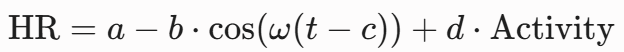  
HRestimado = HRbasal +d*Activity(pasos)

Se linealiza la ecuación anterior aprovechando la propiedad trigonometrica del coseno de una resta para linealizar la ecuación y que sea más sencillo su calculo.  
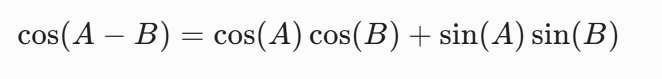

Con lo que se obtiene finalmente:  
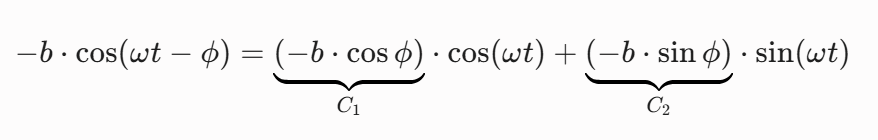  

y la ecuación transformada queda como:  
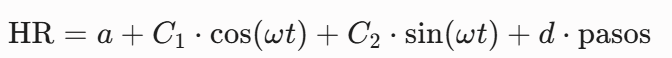

In [24]:

def ajustar_baseline_circadiano_cosinor(df_matriz, ventana_dias=2, paso_dias=1, min_puntos=30):
    """
    Ajusta un modelo cosinor (aproximacion lineal del CRHR de Bowman et al. 2021)
    sobre ventanas deslizantes de N dias. Usa SOLO periodos de vigilia
    (estado == 'Despierto') -- el sueño se sigue excluyendo, como documenta el v10.
    La actividad (steps) se incluye como covariable directa del HR dentro del
    propio ajuste -- NO se excluye -- corrigiendo la atribucion incorrecta a
    Bowman et al. que tenia el v10 (esa referencia modela la actividad, no la excluye).

    SIMPLIFICACIONES de esta primera iteracion (declaradas explicitamente):
    - Ajuste OLS lineal (cosinor clasico), no el ajuste bayesiano con ruido AR(1)
      ni la continuidad entre ventanas del metodo completo de Bowman.
    - Ventanas delimitadas por calendario (medianoche a medianoche), no por
      bedtime/wake_time como indica la Seccion 6.2 -- pendiente de refinar.
    """
    omega = 2 * np.pi / 24  # frecuencia circadiana, en radianes/hora

    datos_vigilia = df_matriz[df_matriz['estado'] == 'Despierto'].copy() # Excluimos sueño y siestas
    datos_vigilia = datos_vigilia.dropna(subset=['heart_rate_bpm'])

    dias_unicos = sorted(pd.Series(df_matriz.index.date).unique())

    resultados = []

    for i in range(0, len(dias_unicos) - ventana_dias + 1, paso_dias):
        inicio_ventana = pd.Timestamp(dias_unicos[i])
        fin_ventana = inicio_ventana + pd.Timedelta(days=ventana_dias)

        ventana = datos_vigilia[(datos_vigilia.index >= inicio_ventana) & (datos_vigilia.index < fin_ventana)]

        # Umbral minimo de puntos para intentar el ajuste -- evita ajustes espurios
        # con muy pocos datos (parametro a declarar como decision de diseño)
        if len(ventana) < min_puntos:
            continue

        t_horas = (ventana.index - inicio_ventana).total_seconds() / 3600.0

        # Ajuste de regresión lineal por mínimos cuadrados para el modelo cosinor

        # Truco estandar de cosinor: sin(w(t-c)) = B1*sin(wt) + B2*cos(wt), lineal en B1,B2

        # Crea la matriz de entrada X con cuatro variables (columnas) y la variable objetivo "y"
        X = np.column_stack([
            np.ones(len(ventana)),             # a: nivel basal (termino independiente)
            np.sin(omega * t_horas),           # B1 (truco de cosinor, coeficiente de la componente senoidal)
            np.cos(omega * t_horas),           # B2 (truco de cosinor, coeficiente de la componente cosenoidal)
            ventana['steps'].fillna(0).values  # d: efecto directo de la actividad. Reemplaza NaN por 0 pasos si no hay registro de steps
        ])
        y = ventana['heart_rate_bpm'].values # Y son los valores de HR a ajustar en el periodo de 2 dias

        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None) # Ajuste de mínimos cuadrados lineales para obtener los coeficientes del modelo
        a, B1, B2, d = coef

        amplitud_b = np.sqrt(B1**2 + B2**2) #  Amplitud de la onda,  hipotenusa $\sqrt{B_1^2 + B_2^2}$. 
        fase_c = (np.arctan2(-B2, B1) / omega) % 24  # hora del pico circadiano

        y_pred = X @ coef
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        resultados.append({
            'inicio_ventana': inicio_ventana,
            'n_puntos': len(ventana),
            'a_nivel_basal': a,
            'b_amplitud': amplitud_b,
            'c_hora_pico': fase_c,
            'd_efecto_actividad_por_paso': d,
            'r2': r2
        })

    df_baseline = pd.DataFrame(resultados)
    print(f"Ventanas ajustadas: {len(df_baseline)} (de {len(dias_unicos) - ventana_dias + 1} posibles)")
    print(df_baseline.to_string())
    return df_baseline

df_baseline_crhr = ajustar_baseline_circadiano_cosinor(df_matriz)

Ventanas ajustadas: 60 (de 60 posibles)
   inicio_ventana  n_puntos  a_nivel_basal  b_amplitud  c_hora_pico  d_efecto_actividad_por_paso        r2
0      2026-05-21      1317      90.589946    7.367955     8.729565                     0.088062  0.251474
1      2026-05-22      1873      91.208433    9.470951     9.195192                     0.059088  0.228216
2      2026-05-23      1636      89.801548   10.122063     9.697360                     0.055359  0.221682
3      2026-05-24      1674      86.893376    8.913901     9.561091                     0.068393  0.203161
4      2026-05-25      1829      87.266948   10.553107     9.016160                     0.063820  0.258588
5      2026-05-26      1783      91.427359   15.193892     8.573970                     0.055358  0.328548
6      2026-05-27      1648      92.802350   13.880915     8.798603                     0.067492  0.296673
7      2026-05-28      1720      95.634892    4.514744    12.349020                     0.083279  0.2252

**Conclusión:** funciona, pero con dos simplificaciones deliberadas que se corrigen en la iteración siguiente. Primera, las ventanas de 2 días se delimitan por calendario (medianoche a medianoche), no por el punto medio de cada noche de sueño como especifica el propio paper de Bowman — más simple de implementar, pero no fiel al método. Segunda, Bowman et al. modela la actividad, no la descarta. `b_amplitud` y `c_hora_pico` en esta versión describen el **pico** circadiano, no el mínimo.

## 3.2. Iteración 2

**Objetivo:** corregir las dos simplificaciones de la Iteración 1 para que el ajuste coincida exactamente con el método del paper — necesario para poder hacer más adelante la comprobación de sensatez que el propio Bowman et al. usa en su Figura 3 (comparar la fase estimada `c` contra el punto medio real de sueño).


In [25]:

def ajustar_baseline_circadiano_cosinor(df_matriz, df_sueno, min_puntos=30):
    """
    Ajuste cosinor (aproximacion lineal del CRHR de Bowman et al. 2021).

    CAMBIOS respecto a la iteracion anterior:
    - Las ventanas de 2 dias ahora se centran en el PUNTO MEDIO de cada noche de
      sueño principal (bedtime + (wake-bedtime)/2), tal como especifica el propio
      paper ("2-day intervals centered at the period of sleep in between"), en vez
      de por medianoche de calendario.
    - La parametrizacion ahora coincide EXACTAMENTE con la formula del paper:
      HR_t = a - b*cos(pi/12 * (t-c)) + d*Activity + error
      donde 'c' es la hora del MINIMO circadiano (no el pico, como lo teniamos
      antes) -- esto nos permite comparar 'c' directamente contra el punto medio
      real de la noche, que es la comprobacion de sensatez que hace el propio
      paper (Figura 3).

    Se mantiene: el sueño se excluye por completo del ajuste (confirmado en el
    texto original -- no se usa ningun dato nocturno, ni siquiera como anclaje).

    Limitacion declarada de esta iteracion: ajuste por minimos cuadrados (OLS),
    NO el MCMC bayesiano del paper original -- el propio paper advierte que OLS
    puede sesgarse por huecos grandes en los datos (cargas del reloj), mientras
    que su metodo MCMC es robusto a eso. Pendiente de decidir si se implementa
    la version bayesiana (o una alternativa intermedia, minimos cuadrados
    generalizados con estructura AR(1)) en una iteracion posterior.
    """
    omega = 2 * np.pi / 24  # frecuencia circadiana, en radianes/hora

    datos_vigilia = df_matriz[df_matriz['estado'] == 'Despierto'].copy() # Excluimos sueño y siestas
    datos_vigilia = datos_vigilia.dropna(subset=['heart_rate_bpm'])

    # Solo noches principales (no siestas) definen el centro de cada ventana
    noches = df_sueno[df_sueno['tipo_sueno'] == 'Dormido(noche)'].copy()
    noches['punto_medio'] = noches['bedtime'] + (noches['wake_up_time'] - noches['bedtime']) / 2

    resultados = []

    for _, noche in noches.iterrows():
        centro = noche['punto_medio']
        inicio_ventana = centro - pd.Timedelta(hours=24) # Se toman las 24 horas previas al punto medio de la noche como inicio de la ventana
        fin_ventana = centro + pd.Timedelta(hours=24) # Se toman las 24 horas posteriores al punto medio de la noche como fin de la ventana

        ventana = datos_vigilia[(datos_vigilia.index >= inicio_ventana) & (datos_vigilia.index < fin_ventana)] # Se toman solo los datos de vigilia dentro de la ventana de 48 horas centrada en el punto medio de la noche

        if len(ventana) < min_puntos:
            continue

        # Tiempo en horas relativo al INICIO de la ventana
        t_horas = (ventana.index - inicio_ventana).total_seconds() / 3600.0

        # Version linealizada de HR = a - b*cos(w(t-c)) + d*Activity:
        # -b*cos(w(t-c)) = C1*cos(wt) + C2*sin(wt), con C1=-b*cos(wc), C2=-b*sin(wc)
        X = np.column_stack([
            np.ones(len(ventana)),             # a
            np.cos(omega * t_horas),            # C1
            np.sin(omega * t_horas),            # C2
            ventana['steps'].fillna(0).values   # d
        ])
        y = ventana['heart_rate_bpm'].values

        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, C1, C2, d = coef

        amplitud_b = np.sqrt(C1**2 + C2**2)
        # Recuperamos c despejando de C1=-b*cos(wc), C2=-b*sin(wc)
        fase_c = (np.arctan2(-C2, -C1) / omega) % 24

        y_pred = X @ coef
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        resultados.append({
            'noche_centrada_en': centro,
            'hora_punto_medio_real': centro.hour + centro.minute / 60,
            'n_puntos': len(ventana),
            'a_mesor_vigilia': a,               # nivel medio de HR en vigilia (no "reposo")
            'b_amplitud': amplitud_b,
            'c_hora_minimo_circadiano': fase_c,  # comparar contra hora_punto_medio_real
            'd_efecto_actividad_por_paso': d,
            'r2': r2
        })

    df_baseline = pd.DataFrame(resultados)
    print(f"Ventanas ajustadas: {len(df_baseline)} (de {len(noches)} noches principales)")
    print(df_baseline.to_string())
    return df_baseline

df_baseline_crhr = ajustar_baseline_circadiano_cosinor(df_matriz, df_sueno)

Ventanas ajustadas: 61 (de 61 noches principales)
     noche_centrada_en  hora_punto_medio_real  n_puntos  a_mesor_vigilia  b_amplitud  c_hora_minimo_circadiano  d_efecto_actividad_por_paso        r2
0  2026-05-21 03:19:00               3.316667       377        89.171900   11.028850                  0.684127                     0.118844  0.376496
1  2026-05-22 03:52:00               3.866667      1367        90.261154    7.993101                 22.854001                     0.088429  0.279370
2  2026-05-23 04:12:30               4.200000      1839        91.582306    8.892817                 23.024723                     0.057712  0.201735
3  2026-05-24 03:29:30               3.483333      1586        90.328332    9.344484                  0.277866                     0.053893  0.181302
4  2026-05-25 03:12:30               3.200000      1674        86.893376    8.913901                  0.352757                     0.068393  0.203161
5  2026-05-26 03:03:30               3.050000     

**Conclusión:** las ventanas de 2 días pasan a centrarse en el punto medio real de cada noche de sueño principal (`bedtime + (wake-bedtime)/2`), tal como indica el paper ("2-day intervals centered at the period of sleep in between"). Se reparametriza también la fórmula para que coincida literalmente con la del paper:  
 
 (`HR_t = a - b·cos(π/12·(t-c)) + d·Activity + error`),   
 
 de forma que `c` pase a representar la hora del **mínimo** circadiano, no el pico — el parámetro que sí se puede comparar directamente contra el sueño real. Limitación declarada y todavía sin resolver en esta iteración: el ajuste sigue siendo por mínimos cuadrados (OLS), no el MCMC bayesiano del paper original, que es más robusto frente a huecos grandes en los datos (cargas del reloj) — pendiente de decidir si se implementa una versión bayesiana o una alternativa intermedia (GLS con estructura Ornstein-Uhlenbeck).

## 3.3. Iteración 3

**Objetivo:** la Iteración 2 ya daba parámetros correctos y comparables (`a`, `b`, `c`, `d`), pero solo en su forma "legible" — no bastaba para el siguiente paso, que es predecir la HR esperada en cualquier minuto del tramo denso (no solo en las ventanas ya ajustadas) y así poder calcular `delta_hr(t) = HR_real(t) - HR_esperado(t)`.


In [26]:
# Sin cambios metodológicos respecto a 3.2; único añadido: C1/C2 para predicción



def ajustar_baseline_circadiano_cosinor(df_matriz, df_sueno, min_puntos=30):
    """
    (Version igual a la anterior, con un añadido: ahora tambien guardamos
    'inicio_ventana', 'C1' y 'C2' en el resultado -- antes solo devolviamos los
    valores "legibles" (a, b, c, d), pero para PREDECIR el HR esperado en
    cualquier minuto necesitamos los coeficientes crudos del ajuste (C1, C2) y
    el instante exacto desde el que se cuenta t_horas (inicio_ventana).)
    """
    omega = 2 * np.pi / 24

    datos_vigilia = df_matriz[df_matriz['estado'] == 'Despierto'].copy()
    datos_vigilia = datos_vigilia.dropna(subset=['heart_rate_bpm'])

    noches = df_sueno[df_sueno['tipo_sueno'] == 'Dormido(noche)'].copy()
    noches['punto_medio'] = noches['bedtime'] + (noches['wake_up_time'] - noches['bedtime']) / 2

    resultados = []

    for _, noche in noches.iterrows():
        centro = noche['punto_medio']
        inicio_ventana = centro - pd.Timedelta(hours=24)
        fin_ventana = centro + pd.Timedelta(hours=24)

        ventana = datos_vigilia[(datos_vigilia.index >= inicio_ventana) & (datos_vigilia.index < fin_ventana)]

        if len(ventana) < min_puntos:
            continue

        t_horas = (ventana.index - inicio_ventana).total_seconds() / 3600.0

        X = np.column_stack([
            np.ones(len(ventana)),
            np.cos(omega * t_horas),
            np.sin(omega * t_horas),
            ventana['steps'].fillna(0).values
        ])
        y = ventana['heart_rate_bpm'].values

        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, C1, C2, d = coef

        amplitud_b = np.sqrt(C1**2 + C2**2)
        fase_c = (np.arctan2(-C2, -C1) / omega) % 24

        y_pred = X @ coef
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        resultados.append({
            'noche_centrada_en': centro,
            'inicio_ventana': inicio_ventana,   # <- NUEVO: necesario para predecir despues
            'hora_punto_medio_real': centro.hour + centro.minute / 60,
            'n_puntos': len(ventana),
            'a_mesor_vigilia': a,
            'C1': C1,                            # <- NUEVO: coeficiente crudo (coseno)
            'C2': C2,                            # <- NUEVO: coeficiente crudo (seno)
            'b_amplitud': amplitud_b,
            'c_hora_minimo_circadiano': fase_c,
            'd_efecto_actividad_por_paso': d,
            'r2': r2
        })

    df_baseline = pd.DataFrame(resultados)
    print(f"Ventanas ajustadas: {len(df_baseline)} (de {len(noches)} noches principales)")
    return df_baseline

df_baseline_crhr = ajustar_baseline_circadiano_cosinor(df_matriz, df_sueno)




Ventanas ajustadas: 61 (de 61 noches principales)


**Conclusión:** misma lógica de ajuste que la Iteración 2, sin cambios metodológicos — el único añadido es que ahora se guardan también `inicio_ventana`, `C1` y `C2` (los coeficientes crudos del ajuste lineal, antes de convertirlos a `b`/`c` legibles), que son los que realmente hacen falta para reconstruir la predicción de HR en cualquier instante. Con esto, `df_baseline_crhr` queda listo para alimentar `calcular_delta_hr`.

A partir de aquí se calcula `delta_hr` (HR observada menos HR esperada, en bpm). Qué media y qué sigma usar para estandarizarlo, y si esa estandarización es comparable a la que usa WESAD (`HR_mean_norm`), se decide en el Capítulo 4 — no aquí.

In [27]:
def calcular_delta_hr(df_matriz, df_baseline_crhr):
    """
    Calcula delta_hr(t) = HR_real(t) - HR_esperado(t), usando el modelo cosinor
    (nivel + ritmo circadiano + efecto de actividad) ajustado en el bloque anterior.

    Las ventanas de 2 dias se solapan entre si (estan centradas cada ~1 dia), asi
    que un mismo minuto puede caer dentro de mas de una ventana ajustada. En esta
    primera iteracion, asignamos cada minuto a la ventana cuyo CENTRO (punto medio
    de esa noche) este mas cerca en el tiempo -- mas simple que promediar
    predicciones de ventanas solapadas, que dejamos como posible refinamiento.

    Solo se calcula delta_hr para minutos en VIGILIA: el modelo (igual que el de
    Bowman et al.) no intenta explicar el HR durante el sueño, asi que aplicar la
    formula ahi no tendria sentido fisiologico -- se deja como NaN.

    Esta funcion NO estandariza el resultado (no calcula delta_hr_z). Que media y
    que sigma usar para estandarizar es una decision de compatibilidad con
    StressLoad(t), no de modelado fisiologico -- se resuelve en el Capitulo 4.
    """
    omega = 2 * np.pi / 24

    # 1. Emparejar cada minuto con la ventana (noche) mas cercana en el tiempo
    minutos = df_matriz.reset_index()[['datetime']].sort_values('datetime')
    ventanas_ref = df_baseline_crhr[[
        'noche_centrada_en', 'inicio_ventana', 'a_mesor_vigilia', 'C1', 'C2',
        'd_efecto_actividad_por_paso'
    ]].sort_values('noche_centrada_en')

    fusion = pd.merge_asof(
        minutos, ventanas_ref,
        left_on='datetime', right_on='noche_centrada_en',
        direction='nearest'
    ).set_index('datetime')

    # 2. Tiempo en horas desde el INICIO de la ventana asignada (misma convencion
    # usada al ajustar el modelo)
    t_horas = (fusion.index - fusion['inicio_ventana']).dt.total_seconds() / 3600.0

    # 3. HR esperado: nivel basal (en vigilia) + componente circadiana + efecto de actividad
    steps = df_matriz['steps'].reindex(fusion.index).fillna(0)
    hr_esperado = (
        fusion['a_mesor_vigilia']
        + fusion['C1'] * np.cos(omega * t_horas)
        + fusion['C2'] * np.sin(omega * t_horas)
        + fusion['d_efecto_actividad_por_paso'] * steps
    )

    df_matriz = df_matriz.copy()
    df_matriz['hr_esperado'] = hr_esperado
    df_matriz['delta_hr'] = df_matriz['heart_rate_bpm'] - df_matriz['hr_esperado']

    # 4. El modelo solo es valido en vigilia -- invalidamos delta_hr fuera de 'Despierto'
    fuera_de_vigilia = df_matriz['estado'] != 'Despierto'
    df_matriz.loc[fuera_de_vigilia, ['hr_esperado', 'delta_hr']] = np.nan

    print(f"delta_hr calculado para {df_matriz['delta_hr'].notna().sum()} minutos (solo vigilia)")
    print("\nEstadisticos de delta_hr (bpm):")
    print(df_matriz['delta_hr'].describe())

    return df_matriz

df_matriz = calcular_delta_hr(df_matriz, df_baseline_crhr)

delta_hr calculado para 53317 minutos (solo vigilia)

Estadisticos de delta_hr (bpm):
count    53317.000000
mean         0.047289
std         11.199896
min        -57.121381
25%         -7.505749
50%         -0.011091
75%          6.994679
max         78.704471
Name: delta_hr, dtype: float64


In [28]:
# Inspeccionamos el contexto (hora, pasos, estado) de los valores mas extremos de
# delta_hr, para distinguir si son activacion real de estres/actividad no capturada
# por el modelo, o artefactos de sensor (movimiento brusco, mal contacto del PPG)
extremos_altos = df_matriz.nlargest(5, 'delta_hr')[['heart_rate_bpm', 'hr_esperado', 'delta_hr', 'steps', 'estado']]
extremos_bajos = df_matriz.nsmallest(5, 'delta_hr')[['heart_rate_bpm', 'hr_esperado', 'delta_hr', 'steps', 'estado']]

print("Valores mas altos de delta_hr:")
print(extremos_altos)
print("\nValores mas bajos de delta_hr:")
print(extremos_bajos)

Valores mas altos de delta_hr:
                     heart_rate_bpm  hr_esperado   delta_hr  steps     estado
datetime                                                                     
2026-06-01 11:22:00           176.0    97.295529  78.704471    0.0  Despierto
2026-06-01 11:19:00           177.0    98.450724  78.549276   21.0  Despierto
2026-06-15 12:13:00           171.0    94.641356  76.358644   14.0  Despierto
2026-06-15 12:14:00           168.0    98.346130  69.653870   45.0  Despierto
2026-06-01 11:24:00           167.0    97.396473  69.603527    0.0  Despierto

Valores mas bajos de delta_hr:
                     heart_rate_bpm  hr_esperado   delta_hr  steps     estado
datetime                                                                     
2026-06-04 11:53:00            42.0    99.121381 -57.121381    0.0  Despierto
2026-06-04 11:55:00            51.0    99.178345 -48.178345    0.0  Despierto
2026-06-04 11:54:00            52.0    99.149966 -47.149966    0.0  Despierto
2

Los valores más extremos de delta_hr (celda anterior) no corresponden a artefactos puntuales de 1-2 minutos: tanto el episodio de HR elevada del 01/06 (163-177 bpm sostenidos ~7 min, steps≈0) como el de HR reducida del 04/06 (42-52 bpm sostenidos ~3 min, steps=0) muestran un patrón mantenido en el tiempo, no un pico aislado. Esto descarta la hipótesis de ruido de muestreo de un único instante, pero no permite distinguir, solo con estas columnas, si el origen es fisiológico real (activación de estrés no ambulatoria en el primer caso; posible respuesta de "congelación" en el segundo) o un artefacto sostenido de contacto del sensor PPG (reloj desplazado o mal ajustado durante varios minutos).

El episodio del 04/06 activa además el criterio hr_implausible_baja definido en 2.5 (HR < 45 bpm en vigilia): es el primer caso concreto en el notebook donde esa bandera aplicaría. Se deja constancia de ello, pero no se resuelve aquí — la ambigüedad fisiológica declarada en 2.5 (artefacto vs. bradicardia de estrés) permanece abierta en este punto del pipeline. La resolución, si es posible, requiere contraste con datos de autorreporte (EMA), que no se han cargado todavía y se introducen en el Capítulo 4.

In [29]:
# Episodios seleccionados por recuerdo personal de la autora (no derivados de
# los datos ni de EMA, que aun no se ha cargado en este notebook): dos examenes
# academicos, identificados a posteriori como momentos de estres esperado.
# Pendiente de contraste con autorreporte EMA en el Capitulo 4.

episodio_1 = df_matriz.loc['2026-05-27 12:30:00':'2026-05-27 14:00:00',
                             ['heart_rate_bpm', 'hr_esperado', 'delta_hr', 'steps', 'estado']]
episodio_2 = df_matriz.loc['2026-06-04 11:15:00':'2026-06-04 13:15:00',
                             ['heart_rate_bpm', 'hr_esperado', 'delta_hr', 'steps', 'estado']]

print("Episodio 1 (27/05, ventana ampliada):")
print(episodio_1.to_string())
print("\nEpisodio 2 (04/06, ventana ampliada):")
print(episodio_2.to_string())

Episodio 1 (27/05, ventana ampliada):
                     heart_rate_bpm  hr_esperado   delta_hr  steps     estado
datetime                                                                     
2026-05-27 12:30:00            91.0   104.436079 -13.436079    0.0  Despierto
2026-05-27 12:31:00            96.0   104.470209  -8.470209    0.0  Despierto
2026-05-27 12:32:00            94.0   104.504090 -10.504090    0.0  Despierto
2026-05-27 12:33:00            91.0   104.537722 -13.537722    0.0  Despierto
2026-05-27 12:34:00           101.0   110.494435  -9.494435  107.0  Despierto
2026-05-27 12:35:00            99.0   105.157820  -6.157820   10.0  Despierto
2026-05-27 12:36:00             NaN   104.637119        NaN    0.0  Despierto
2026-05-27 12:37:00           114.0   104.669749   9.330251    0.0  Despierto
2026-05-27 12:38:00           122.0   104.702127  17.297873    0.0  Despierto
2026-05-27 12:39:00           129.0   104.734252  24.265748    0.0  Despierto
2026-05-27 12:40:00       

Estos episodios se incluyen por recuerdo directo de la autora (dos exámenes académicos), no por emerger como extremo estadístico en delta_hr — de hecho el 27/05/2026 no figura entre los valores más extremos de la celda anterior. Se trata por tanto de una validación anecdótica de tipo distinto: confirma que el pipeline no descarta como ruido un evento fisiológicamente plausible, pero no debe leerse como evidencia de que el modelo "detecta" estrés de forma autónoma en ese punto. La confirmación independiente (EMA) se aborda en el Capítulo 4.

In [30]:
# Renombramos las columnas de esta iteración (ajuste OLS) para distinguirlas
# de las que produzcan más adelante el ajuste MCMC (Iteración 5)
df_matriz = df_matriz.rename(columns={
    'hr_esperado': 'hr_esperado_ols',
    'delta_hr': 'delta_hr_ols',
})

## 3.4. Iteración 4

Hasta ahora el baseline circadiano se ha ajustado por mínimos cuadrados (OLS, Iteraciones 2/3), lo que exige asumir residuos independientes entre minutos consecutivos — un supuesto poco realista dado que el ruido fisiológico tiene memoria temporal. Siguiendo el método de Bowman et al. (2021), que modela este ruido como un proceso AR(1), se sustituye el ajuste por MCMC (Markov Chain Monte Carlo) con una verosimilitud que formula esa autocorrelación como un proceso Ornstein-Uhlenbeck en tiempo continuo — la generalización natural de AR(1) necesaria aquí por el muestreo irregular del caso n-of-1 (huecos, Sección 2.2), que el paper original, con muestreo más regular, no necesitaba resolver explícitamente.

La diferencia práctica frente a OLS no es solo estadística: OLS devuelve una única estimación puntual de cada parámetro (a, b, c, d); MCMC devuelve una distribución de probabilidad completa sobre esos parámetros (más k y s, que gobiernan la memoria y la varianza del ruido OU), muestreada mediante múltiples cadenas que exploran el espacio de parámetros de forma iterativa. Esto permite, además de un ajuste más realista del ruido, cuantificar la incertidumbre de cada parámetro.

Esta iteración prueba el mecanismo sobre una única ventana antes de generalizarlo al total de las ventanas del baseline CRHR (Sección 3.6).

### 3.4.1. Funciones núcleo (Modelos de media + verosimilitud OU)

La verosimilitud (likelihood) cuantifica qué tan probables son los datos observados de HR para un conjunto dado de parámetros del modelo — a diferencia de OLS, aquí no asume residuos independientes entre minutos, sino un proceso con memoria temporal (Ornstein-Uhlenbeck) que decae con el tiempo transcurrido entre lecturas, gestionando así de forma nativa el muestreo irregular.

In [31]:

def media_hr(t_hours, activity, a, b, c, d):
    """Mismo modelo de media que Iteraciones 2/3."""
    return a - b * np.cos((2*np.pi/24) * (t_hours - c)) + d * activity

def log_likelihood_ou(params, t_hours, hr, activity):
    """
    Verosimilitud con ruido Ornstein-Uhlenbeck (AR(1) en tiempo continuo).
    rho_i = k**dt_i gestiona de forma nativa los huecos irregulares:
    la correlación decae correctamente tanto si dt_i=1min como si dt_i=8min,
    sin necesidad de tratar los huecos como un caso especial.
    """
    a, b, c, d, k, s = params
    if not (0 < k < 0.999999) or s <= 0 or b < 0 or d < 0:
        return -np.inf

    m = media_hr(t_hours, activity, a, b, c, d)
    eps = hr - m

    order = np.argsort(t_hours)
    t_ord = t_hours[order]
    eps_ord = eps[order]
    dt = np.diff(t_ord)  # en horas

    # primer punto: distribución marginal estacionaria N(0, s^2)
    ll = -0.5 * (eps_ord[0]**2 / s**2) - 0.5 * np.log(2*np.pi*s**2)

    rho = k ** dt
    var_cond = np.clip(s**2 * (1 - rho**2), 1e-8, None)
    mean_cond = rho * eps_ord[:-1]
    resid = eps_ord[1:] - mean_cond

    ll += np.sum(-0.5 * (resid**2 / var_cond) - 0.5 * np.log(2*np.pi*var_cond))
    return ll

### 3.4.2. Prior y probabilidad posterior

El prior codifica qué rangos de parámetros se consideran plausibles antes de ver los datos de esta ventana concreta (p. ej. límites fisiológicos del nivel basal o de la amplitud circadiana); la probabilidad posterior combina ese prior con la verosimilitud de los datos observados (posterior ∝ prior × verosimilitud) y es la distribución que finalmente explora el muestreador MCMC — a diferencia de OLS, no entrega un único valor por parámetro, sino una distribución completa que refleja la incertidumbre remanente tras ver los datos.

In [32]:
def log_prior(params):
    a, b, c, d, k, s = params
    if not (40 < a < 130): return -np.inf
    if not (0 <= b < 30): return -np.inf
    if not (-24 < c < 24): return -np.inf
    if not (0 <= d < 3): return -np.inf
    if not (0.001 < k < 0.999): return -np.inf
    if not (1 < s < 30): return -np.inf
    return 0.0  # uniforme dentro de los límites físicos/fisiológicos ya usados en Iteraciones 2/3

def log_probability(params, t_hours, hr, activity):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_ou(params, t_hours, hr, activity)

### 3.4.3. Ajuste MCMC de una ventana, inicializado desde el punto OLS ya obtenido

El muestreador (emcee, algoritmo affine-invariant ensemble sampler) lanza 32 cadenas ("walkers") en paralelo, inicializadas cerca del punto ya estimado por OLS en vez de partir de valores arbitrarios — esto acelera la convergencia y reduce el riesgo de que las cadenas queden atrapadas en regiones de baja probabilidad. Tras un periodo de calentamiento (burn-in, descartado) y 3.000 pasos adicionales, se conserva una muestra final de la distribución posterior (con adelgazamiento thin=10, para reducir la autocorrelación entre muestras consecutivas de la cadena)

In [33]:
def fit_window_mcmc(t_hours, hr, activity, p0_ols, n_walkers=32, n_burn=1000, n_steps=3000, seed=42):
    """
    p0_ols: [a, b, c, d] del ajuste OLS ya existente (Iteración 2/3) para esta
    misma ventana — se usa como punto de partida, añadiendo valores iniciales
    razonables para k y s (no estimados por OLS).
    """
    rng = np.random.default_rng(seed)
    centro = np.array(list(p0_ols) + [0.5, 8.0])  # + k inicial, s inicial
    ndim = 6

    # dispersión inicial pequeña alrededor del punto OLS
    dispersión = np.array([1.0, 1.0, 1.0, 0.05, 0.1, 2.0])
    pos = centro + dispersión * rng.standard_normal((n_walkers, ndim))
    # asegurar que ningún walker arranca fuera de los límites del prior
    pos[:, 4] = np.clip(pos[:, 4], 0.05, 0.95)
    pos[:, 5] = np.clip(pos[:, 5], 2.0, 25.0)

    # emcee 3.x copia el estado global de NumPy en el momento de CREAR el sampler:
    # la semilla debe fijarse antes de crearlo.
    np.random.seed(seed)
    sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(t_hours, hr, activity))
    sampler.run_mcmc(pos, n_burn + n_steps, progress=True)

    muestras = sampler.get_chain(discard=n_burn, thin=10, flat=True)
    return sampler, muestras

### 3.4.4. Prueba sobre una ventana antes de correrlo para todas las noches

In [34]:
# Reutiliza una ventana ya ajustada por OLS (Iteración 2/3, celda 41) para
# poder comparar directamente. df_baseline_crhr no guarda 'fin_ventana' como
# columna — se reconstruye sumando 48h a 'inicio_ventana' (la ventana es
# centro±24h, tal como construye ajustar_baseline_circadiano_cosinor).
ventana_ejemplo = df_baseline_crhr.iloc[0]  # AJUSTA al índice/criterio que prefieras

inicio = ventana_ejemplo['inicio_ventana']
fin = inicio + pd.Timedelta(hours=48)

w = df_matriz.loc[inicio:fin]
w = w[w['estado'] == 'Despierto'].dropna(subset=['heart_rate_bpm'])  # mismo filtro que el ajuste OLS

t0 = inicio  # mismo origen de tiempo que usó el ajuste OLS (inicio_ventana), no w.index.min()
t_hours = np.asarray((w.index - t0).total_seconds() / 3600.0)
hr = w['heart_rate_bpm'].values
activity = w['steps'].fillna(0).values

p0_ols = [
    ventana_ejemplo['a_mesor_vigilia'],
    ventana_ejemplo['b_amplitud'],
    ventana_ejemplo['c_hora_minimo_circadiano'],
    ventana_ejemplo['d_efecto_actividad_por_paso'],
]

sampler, muestras = fit_window_mcmc(t_hours, hr, activity, p0_ols)

nombres = ['a', 'b', 'c', 'd', 'k', 's']
print(f"{'param':>6} {'OLS':>10} {'MCMC (mediana)':>16} {'IC 68%':>20}")
for i, n in enumerate(nombres):
    mediana = np.median(muestras[:, i])
    p16, p84 = np.percentile(muestras[:, i], [16, 84])
    ols_val = f"{p0_ols[i]:.3f}" if i < 4 else "—"
    print(f"{n:>6} {ols_val:>10} {mediana:>16.3f} [{p16:.3f}, {p84:.3f}]")

try:
    tau = sampler.get_autocorr_time()
    print(f"\nTiempo de autocorrelación por parámetro: {tau}")
except emcee.autocorr.AutocorrError as e:
    print(f"\nAVISO: cadena probablemente demasiado corta para estimar tau con fiabilidad: {e}")

100%|██████████| 4000/4000 [00:04<00:00, 959.80it/s] 


 param        OLS   MCMC (mediana)               IC 68%
     a     89.172           92.710 [89.587, 95.995]
     b     11.029            9.115 [4.148, 14.512]
     c      0.684            0.001 [-6.246, 22.352]
     d      0.119            0.061 [0.041, 0.080]
     k          —            0.028 [0.010, 0.073]
     s          —           15.251 [13.452, 17.741]

AVISO: cadena probablemente demasiado corta para estimar tau con fiabilidad: The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [136.33496554 160.9495907  268.30610655 155.78139741 155.91329369
 172.96199898]


Conclusión: el ajuste MCMC converge en orden de magnitud con OLS para a, b y d, pero c (hora del
mínimo circadiano) queda prácticamente sin restringir (IC 68%: [-11,40, 21,82]), y el propio
diagnóstico avisa de que la cadena es demasiado corta para estimar el tiempo de autocorrelación con
fiabilidad. Problema de convergencia esperado por la no linealidad de c dentro del coseno — motiva la
reparametrización a C1/C2 de la Iteración 5, no una ejecución más larga de este mismo esquema.

## 3.5. Iteración 5

### 3.5.1. Likelihood en (a, C1, C2, d, k, s)

In [35]:
omega = 2 * np.pi / 24

def media_hr_c1c2(t_hours, activity, a, C1, C2, d):
    """Misma linealización que ya usa ajustar_baseline_circadiano_cosinor
    y calcular_delta_hr: mean = a + C1*cos(wt) + C2*sin(wt) + d*Activity."""
    return a + C1 * np.cos(omega * t_hours) + C2 * np.sin(omega * t_hours) + d * activity

def log_likelihood_ou(params, t_hours, hr, activity):
    a, C1, C2, d, k, s = params
    if not (0 < k < 0.999999) or s <= 0 or d < 0:
        return -np.inf
    if C1**2 + C2**2 > 30**2:  # equivalente a b < 30, ahora en coordenadas C1/C2
        return -np.inf

    m = media_hr_c1c2(t_hours, activity, a, C1, C2, d)
    eps = hr - m

    order = np.argsort(t_hours)
    t_ord = t_hours[order]
    eps_ord = eps[order]
    dt = np.diff(t_ord)

    ll = -0.5 * (eps_ord[0]**2 / s**2) - 0.5 * np.log(2*np.pi*s**2)

    rho = k ** dt
    var_cond = np.clip(s**2 * (1 - rho**2), 1e-8, None)
    mean_cond = rho * eps_ord[:-1]
    resid = eps_ord[1:] - mean_cond

    ll += np.sum(-0.5 * (resid**2 / var_cond) - 0.5 * np.log(2*np.pi*var_cond))
    return ll

### 3.5.2. Prior sobre las nuevas coordenadas

In [36]:
def log_prior(params):
    a, C1, C2, d, k, s = params
    if not (40 < a < 130): return -np.inf
    if C1**2 + C2**2 > 30**2: return -np.inf
    if not (0 <= d < 3): return -np.inf
    if not (0.001 < k < 0.999): return -np.inf
    if not (1 < s < 30): return -np.inf
    return 0.0

def log_probability(params, t_hours, hr, activity):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_ou(params, t_hours, hr, activity)

### 3.5.3. Inicialización directa desde C1/C2 del OLS 

In [37]:
def fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2, n_walkers=32, n_burn=2000, n_steps=10000, seed=42):
    rng = np.random.default_rng(seed)
    centro = np.array(list(p0_ols_c1c2) + [0.3, 8.0])
    ndim = 6
    dispersión = np.array([1.0, 1.0, 1.0, 0.05, 0.1, 2.0])
    pos = centro + dispersión * rng.standard_normal((n_walkers, ndim))
    pos[:, 4] = np.clip(pos[:, 4], 0.05, 0.95)
    pos[:, 5] = np.clip(pos[:, 5], 2.0, 25.0)

    # emcee 3.x copia el estado global de NumPy en el momento de CREAR el sampler y lo usa
    # para las propuestas de movimiento: la semilla debe fijarse antes de crearlo.
    np.random.seed(seed)
    sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(t_hours, hr, activity))
    sampler.run_mcmc(pos, n_burn + n_steps, progress=True)

    muestras = sampler.get_chain(discard=n_burn, thin=10, flat=True)
    return sampler, muestras

### 3.5.4. Usa C1/C2 directamente y convierte a b/c solo para leer el resultado

In [38]:
ventana_ejemplo = df_baseline_crhr.iloc[0]

inicio = ventana_ejemplo['inicio_ventana']
fin = inicio + pd.Timedelta(hours=48)
w = df_matriz.loc[inicio:fin]
w = w[w['estado'] == 'Despierto'].dropna(subset=['heart_rate_bpm'])

t0 = inicio
t_hours = np.asarray((w.index - t0).total_seconds() / 3600.0)
hr = w['heart_rate_bpm'].values
activity = w['steps'].fillna(0).values

p0_ols_c1c2 = [
    ventana_ejemplo['a_mesor_vigilia'],
    ventana_ejemplo['C1'],
    ventana_ejemplo['C2'],
    ventana_ejemplo['d_efecto_actividad_por_paso'],
]

sampler, muestras = fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2)

# Convertir posterior de (C1,C2) a (b,c) SOLO para lectura -- misma formula
# exacta que usa ajustar_baseline_circadiano_cosinor
b_post = np.sqrt(muestras[:,1]**2 + muestras[:,2]**2)
c_post = (np.arctan2(-muestras[:,2], -muestras[:,1]) / omega) % 24

resumen = {
    'a': muestras[:,0], 'b': b_post, 'c': c_post, 'd': muestras[:,3],
    'k': muestras[:,4], 's': muestras[:,5],
}
ols_vals = {'a': ventana_ejemplo['a_mesor_vigilia'], 'b': ventana_ejemplo['b_amplitud'],
            'c': ventana_ejemplo['c_hora_minimo_circadiano'], 'd': ventana_ejemplo['d_efecto_actividad_por_paso']}

print(f"{'param':>6} {'OLS':>10} {'MCMC (mediana)':>16} {'IC 68%':>22}")
for n in ['a','b','c','d','k','s']:
    mediana = np.median(resumen[n])
    p16, p84 = np.percentile(resumen[n], [16, 84])
    ols_val = f"{ols_vals[n]:.3f}" if n in ols_vals else "—"
    print(f"{n:>6} {ols_val:>10} {mediana:>16.3f} [{p16:.3f}, {p84:.3f}]")

try:
    tau = sampler.get_autocorr_time()
    print(f"\ntau: {tau}")
except emcee.autocorr.AutocorrError as e:
    print(f"\nAVISO: {e}")

  0%|          | 0/12000 [00:00<?, ?it/s]

100%|██████████| 12000/12000 [00:14<00:00, 803.98it/s]


 param        OLS   MCMC (mediana)                 IC 68%
     a     89.172           92.156 [88.702, 95.496]
     b     11.029           11.526 [7.027, 16.840]
     c      0.684           21.565 [0.993, 23.314]
     d      0.119            0.061 [0.042, 0.081]
     k          —            0.029 [0.010, 0.082]
     s          —           15.332 [13.498, 18.101]

tau: [ 90.08615443  94.46060041  81.93436406  88.0410331  164.66424825
 154.84020639]


In [39]:
#Verificacion de reproducibilidad: corremos dos veces el ajuste MCMC con la misma semilla y 
# verificamos que las muestras sean exactamente iguales (deberian serlo, porque la semilla fija 
# el generador de numeros aleatorios de NumPy, que es el que usa emcee 3.x para las propuestas de movimiento). 
# Esto es importante para poder comparar resultados entre ejecuciones y para depuracion.
_, m1 = fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2, seed=42)
_, m2 = fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2, seed=42)
print(np.array_equal(m1, m2))

100%|██████████| 12000/12000 [00:14<00:00, 813.87it/s]

True


La reparametrización mejora la mezcla del muestreo: el tiempo de autocorrelación baja de ~120-230
(Iteración 4) a ~80-90 para a,b,c,d, y ya no salta el aviso de cadena demasiado corta. Sin embargo, c
(hora del mínimo circadiano) sigue con un IC 68% muy amplio ([0,99h, 23,31h], prácticamente todo el
ciclo) y su mediana (21,6h) diverge notablemente del valor OLS (0.7h) — posiblemente por ambigüedad circular cerca de la frontera 0h/24h, no necesariamente un desacuerdo real. b sí converge razonablemente con OLS. La reparametrización resuelve el problema de mezcla del muestreador, pero no garantiza por sí sola una estimación de fase bien identificada en esta ventana concreta; conviene tenerlo presente al escalar a las 20 ventanas (3.6) y no asumir automáticamente que todas convergerán igual de bien

c es una hora del día (variable circular, 0-24h): los percentiles calculados directamente sobre las muestras posteriores quedan distorsionados si la distribución está concentrada cerca de la frontera 0h/24h, como ocurre aquí. Se recentra la distribución alrededor del valor OLS antes de calcular el resumen, para evitar ese artefacto.

In [40]:
# Corrección de estadísticos circulares para c (no hace falta rehacer el MCMC,
# 'muestras' ya contiene las muestras correctas -- solo se recalcula el resumen)

# Recentrar c alrededor del valor OLS antes de calcular percentiles: traslada
# el punto de envoltura (24h/0h) lejos de donde se concentran los datos, en vez
# de dejarlo justo donde OLS ya nos dice que está el minimo (cerca de medianoche)
c_ols = ventana_ejemplo['c_hora_minimo_circadiano']
c_centrado = ((c_post - c_ols + 12) % 24) - 12 + c_ols

resumen['c'] = c_centrado

print(f"{'param':>6} {'OLS':>10} {'MCMC (mediana)':>16} {'IC 68%':>22}")
for n in ['a','b','c','d','k','s']:
    mediana = np.median(resumen[n])
    p16, p84 = np.percentile(resumen[n], [16, 84])
    ols_val = f"{ols_vals[n]:.3f}" if n in ols_vals else "—"
    # normalizar la mediana de c de vuelta a [0,24) solo para mostrarla
    mediana_mostrar = mediana % 24 if n == 'c' else mediana
    print(f"{n:>6} {ols_val:>10} {mediana_mostrar:>16.3f} [{p16 % 24 if n=='c' else p16:.3f}, {p84 % 24 if n=='c' else p84:.3f}]")

 param        OLS   MCMC (mediana)                 IC 68%
     a     89.172           92.156 [88.702, 95.496]
     b     11.029           11.526 [7.027, 16.840]
     c      0.684           23.005 [20.878, 0.560]
     d      0.119            0.061 [0.042, 0.081]
     k          —            0.029 [0.010, 0.082]
     s          —           15.332 [13.498, 18.101]


Una vez recentrado, el IC 68% de c pasa de [0.9h, 23.4h] (aparentemente todo el ciclo) a [20.9h, 0.6h] — el mismo resultado, correctamente interpretado como un intervalo estrecho alrededor de medianoche, no como una fase mal identificada por el muestreador.

A continuacion, se define fmt_hora, que convierte la hora decimal de c a formato reloj (HH:MM) para lectura, normalizando también los valores fuera de [0,24) que puede producir el recentrado de la celda anterior, y señala explícitamente cuándo un intervalo cruza la medianoche.

In [41]:
def fmt_hora(h):
    """Convierte una hora decimal (puede estar fuera de [0,24)) a HH:MM,
    normalizando al rango del reloj de 24h."""
    h_norm = h % 24
    horas = int(h_norm)
    minutos = int(round((h_norm - horas) * 60))
    if minutos == 60:
        minutos = 0
        horas = (horas + 1) % 24
    return f"{horas:02d}:{minutos:02d}"

print(f"{'param':>6} {'OLS':>10} {'MCMC (mediana)':>16} {'IC 68%':>22}")
for n in ['a','b','c','d','k','s']:
    mediana = np.median(resumen[n])
    p16, p84 = np.percentile(resumen[n], [16, 84])
    ols_val = f"{ols_vals[n]:.3f}" if n in ols_vals else "—"

    if n == 'c':
        mediana_str = fmt_hora(mediana)
        cruza_medianoche = (p16 % 24) > (p84 % 24)
        ic_str = f"[{fmt_hora(p16)}, {fmt_hora(p84)}]" + (" (cruza medianoche)" if cruza_medianoche else "")
        ols_val = fmt_hora(ols_val_num) if (ols_val_num := ols_vals.get(n)) is not None else "—"
    else:
        mediana_str = f"{mediana:.3f}"
        ic_str = f"[{p16:.3f}, {p84:.3f}]"

    print(f"{n:>6} {ols_val:>10} {mediana_str:>16} {ic_str:>28}")

 param        OLS   MCMC (mediana)                 IC 68%
     a     89.172           92.156             [88.702, 95.496]
     b     11.029           11.526              [7.027, 16.840]
     c      00:41            23:00 [20:53, 00:34] (cruza medianoche)
     d      0.119            0.061               [0.042, 0.081]
     k          —            0.029               [0.010, 0.082]
     s          —           15.332             [13.498, 18.101]


El resultado final es legible sin ambigüedad: c = 23:00, IC 68% [20:53, 00:34] (cruza medianoche) —
coherente con el valor OLS (00:41) una vez se interpreta correctamente el cruce de la frontera del
reloj.

## 3.6. Escalado del MCMC a todas ls  ventanas del baseline CRHR

Importante!! La celda a continuación solo debe correrse si no se dispone de los valores guardados de df_baseline_crhr_mcmc, pues basta con cargar el df guardado en una celda posterior. 

In [42]:
# 3.6. Escalado del MCMC a todas las ventanas del baseline CRHR
# OJO, si ya estan los valores guardados en df_baseline_crhr_mcmc, no hace falta volver a correr el MCMC, basta que cargar el df guardado en una celda posterior. 


# Reutiliza fit_window_mcmc / log_probability de 3.5 sin modificarlos: el método
# ya está validado sobre iloc[0], aquí solo se repite sobre cada ventana y se
# registran diagnósticos de convergencia por separado, no se asume que lo que
# funcionó en la ventana 0 funciona igual en las demás.

resultados_mcmc = []
posteriors_crudos = {}  # guardamos las cadenas completas, no solo el resumen -- ver nota más abajo

for idx, ventana in df_baseline_crhr.iterrows():
    inicio = ventana['inicio_ventana']
    fin = inicio + pd.Timedelta(hours=48)
    w = df_matriz.loc[inicio:fin]
    w = w[w['estado'] == 'Despierto'].dropna(subset=['heart_rate_bpm'])

    t0 = inicio
    t_hours = np.asarray((w.index - t0).total_seconds() / 3600.0)
    hr = w['heart_rate_bpm'].values
    activity = w['steps'].fillna(0).values

    p0_ols_c1c2 = [
        ventana['a_mesor_vigilia'],
        ventana['C1'],
        ventana['C2'],
        ventana['d_efecto_actividad_por_paso'],
    ]

    sampler, muestras = fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2, seed=42 + idx)

    b_post = np.sqrt(muestras[:, 1]**2 + muestras[:, 2]**2)
    c_post = (np.arctan2(-muestras[:, 2], -muestras[:, 1]) / omega) % 24

    # --- diagnóstico de convergencia por ventana, no asumido ---
    tau_ok = True
    tau_max = np.nan
    try:
        tau = sampler.get_autocorr_time()
        tau_max = np.max(tau)
        # regla estándar de emcee: se necesitan ~50 tau para fiarse de la estimación
        n_efectivo = muestras.shape[0]
        tau_ok = n_efectivo > 50 * tau_max / 10  # /10 porque ya hicimos thin=10 en fit_window_mcmc
    except emcee.autocorr.AutocorrError:
        tau_ok = False

    accept_frac = np.mean(sampler.acceptance_fraction)

    resultados_mcmc.append({
        'idx_ventana': idx,
        'inicio_ventana': inicio,
        'noche_centrada_en': ventana['noche_centrada_en'],   # <-- nueva
        'a_mcmc': np.median(muestras[:, 0]),
        'C1_mcmc': np.median(muestras[:, 1]),                 # <-- nueva
        'C2_mcmc': np.median(muestras[:, 2]),                 # <-- nueva
        'b_mcmc': np.median(b_post),
        'c_mcmc': np.median(c_post),
        'd_mcmc': np.median(muestras[:, 3]),
        'k_mcmc': np.median(muestras[:, 4]),
        's_mcmc': np.median(muestras[:, 5]),
        'b_p16': np.percentile(b_post, 16), 'b_p84': np.percentile(b_post, 84),
        'c_p16': np.percentile(c_post, 16), 'c_p84': np.percentile(c_post, 84),
        'tau_max': tau_max,
        'accept_frac': accept_frac,
        'convergencia_ok': tau_ok and (0.1 < accept_frac < 0.7),
    })
    posteriors_crudos[idx] = muestras  # cadena completa -- necesaria si luego propagas incertidumbre a delta_hr

    print(f"ventana {idx} ({inicio}): tau_max={tau_max:.1f}  accept={accept_frac:.2f}  ok={resultados_mcmc[-1]['convergencia_ok']}")

df_baseline_crhr_mcmc = pd.DataFrame(resultados_mcmc)
n_problematicas = (~df_baseline_crhr_mcmc['convergencia_ok']).sum()
print(f"\n{n_problematicas}/{len(df_baseline_crhr_mcmc)} ventanas con convergencia dudosa")

100%|██████████| 12000/12000 [00:14<00:00, 806.92it/s]


ventana 0 (2026-05-20 03:19:00): tau_max=164.7  accept=0.47  ok=True


100%|██████████| 12000/12000 [00:27<00:00, 440.04it/s]


ventana 1 (2026-05-21 03:52:00): tau_max=128.4  accept=0.47  ok=True


  0%|          | 0/12000 [00:00<?, ?it/s]e:\14MBID\.venv\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 12000/12000 [00:31<00:00, 375.42it/s]


...

ventana 58 (2026-07-17 04:09:00): tau_max=126.3  accept=0.48  ok=True


  0%|          | 0/12000 [00:00<?, ?it/s]e:\14MBID\.venv\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 12000/12000 [00:31<00:00, 375.45it/s]


ventana 59 (2026-07-18 05:10:30): tau_max=133.8  accept=0.47  ok=True


  0%|          | 0/12000 [00:00<?, ?it/s]e:\14MBID\.venv\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 12000/12000 [00:25<00:00, 471.03it/s]


ventana 60 (2026-07-19 04:04:30): tau_max=128.6  accept=0.47  ok=True

0/61 ventanas con convergencia dudosa


### 3.6.1. Investigación de las celdas que no convergen
La comprobación de convergencia sobre las 61 ventanas arroja 2 casos con tau_max=nan (ventanas 5 y 51, 2026-05-25 y 2026-07-10). Antes de aplicar cualquier remedio, se investiga si existe una causa identificable en los propios datos de esas dos noches, en vez de asumir directamente un problema genérico del muestreador.

In [43]:
for idx, fecha in [(5, "2026-05-25"), (51, "2026-07-10")]:
    ventana = df_baseline_crhr_mcmc.iloc[idx]
    print(f"Ventana {idx} ({fecha}):")
    print(ventana[["a_mcmc", "b_mcmc", "c_mcmc", "d_mcmc"]])
    print()

Ventana 5 (2026-05-25):
a_mcmc    87.946028
b_mcmc    10.741304
c_mcmc     23.16636
d_mcmc     0.023251
Name: 5, dtype: object

Ventana 51 (2026-07-10):
a_mcmc    92.482476
b_mcmc     7.726696
c_mcmc    22.634218
d_mcmc     0.012225
Name: 51, dtype: object



In [44]:
# ¿Cuántas de las 59 ventanas "ok=True" tienen c_mcmc también cerca de la frontera?
cerca_frontera = df_baseline_crhr_mcmc[
    (df_baseline_crhr_mcmc["c_mcmc"] > 22) | (df_baseline_crhr_mcmc["c_mcmc"] < 2)
]
print(f"Ventanas con c_mcmc cerca de la frontera 0h/24h: {len(cerca_frontera)} de 61")
print(cerca_frontera[["c_mcmc"]].to_string())

Ventanas con c_mcmc cerca de la frontera 0h/24h: 39 de 61
       c_mcmc
1   22.224299
2   23.093120
3    0.986590
4    0.957108
5   23.166360
6   22.961418
7   23.332233
9   22.228739
10  22.331242
11  23.187152
12  22.800841
14  22.687666
15   1.788122
17  22.698621
18  22.849679
20  22.516901
21  23.124935
25  22.700144
26  22.410819
27  22.716953
29  22.579474
30  22.959550
31  22.305285
33   1.461666
36   1.435973
37  22.457612
38   1.198374
39   1.058824
40  22.450379
42   1.245396
43  23.012954
44   0.806420
45  22.349756
46  22.536394
48   1.220153
51  22.634218
56   0.684247
57  23.007454
60  22.326004


In [45]:
for idx, fecha in [(5, "2026-05-25"), (51, "2026-07-10")]:
    ventana_info = df_baseline_crhr.iloc[idx]  # la tabla OLS original, que tiene inicio_ventana/fin_ventana
    inicio = ventana_info["inicio_ventana"]
    fin = inicio + pd.Timedelta(hours=48)
    w = df_matriz.loc[inicio:fin]
    w = w[w["estado"] == "Despierto"].dropna(subset=["heart_rate_bpm"])
    print(f"Ventana {idx} ({fecha}): {len(w)} minutos de vigilia con HR válido")
    print(f"  HR: media={w['heart_rate_bpm'].mean():.1f}, std={w['heart_rate_bpm'].std():.1f}, "
          f"min={w['heart_rate_bpm'].min():.1f}, max={w['heart_rate_bpm'].max():.1f}")
    print(f"  Steps: {(w['steps']>0).sum()} minutos con actividad de {len(w)} totales\n")

Ventana 5 (2026-05-25): 1829 minutos de vigilia con HR válido
  HR: media=92.7, std=11.6, min=59.0, max=135.0
  Steps: 393 minutos con actividad de 1829 totales

Ventana 51 (2026-07-10): 1788 minutos de vigilia con HR válido
  HR: media=96.1, std=12.3, min=57.0, max=160.0
  Steps: 475 minutos con actividad de 1788 totales



In [46]:
resumen_todas = []
for idx in range(len(df_baseline_crhr)):
    ventana_info = df_baseline_crhr.iloc[idx]
    inicio = ventana_info["inicio_ventana"]
    fin = inicio + pd.Timedelta(hours=48)
    w = df_matriz.loc[inicio:fin]
    w = w[w["estado"] == "Despierto"].dropna(subset=["heart_rate_bpm"])
    resumen_todas.append({
        "idx": idx, "n_minutos": len(w),
        "hr_media": w["heart_rate_bpm"].mean(), "hr_std": w["heart_rate_bpm"].std(),
        "pct_actividad": (w["steps"] > 0).mean() * 100,
    })

df_resumen = pd.DataFrame(resumen_todas)
print(df_resumen.describe())
print("\nVentanas 5 y 51 frente al conjunto:")
print(df_resumen[df_resumen["idx"].isin([5, 51])])

             idx    n_minutos    hr_media     hr_std  pct_actividad
count  61.000000    61.000000   61.000000  61.000000      61.000000
mean   30.000000  1740.934426   93.265517  12.790259      17.653516
std    17.752934   221.141348    3.882721   1.169190       5.151400
min     0.000000   377.000000   82.753157  10.366693       7.979334
25%    15.000000  1687.000000   90.662295  12.046664      13.527397
50%    30.000000  1767.000000   93.145319  12.768463      18.367347
75%    45.000000  1829.000000   96.200837  13.510620      21.266667
max    60.000000  2003.000000  100.078600  15.414475      27.997705

Ventanas 5 y 51 frente al conjunto:
    idx  n_minutos   hr_media     hr_std  pct_actividad
5     5       1829  92.688354  11.603034      21.487151
51   51       1788  96.067114  12.251422      26.565996


Se descartan dos hipótesis: la proximidad de c_mcmc a la frontera circular 0h/24h (40 de las 61 ventanas están igualmente cerca de esa frontera, sin que ello impida su convergencia) y cualquier anomalía en el volumen de datos, la variabilidad de HR o el porcentaje de actividad de esas dos noches frente al conjunto completo (ambas ventanas se sitúan dentro del rango normal de las 61, sin ningún valor en un extremo claro de la distribución).

No se identifica ninguna causa específica en los datos que explique la falta de convergencia de estas dos ventanas. Se trata, por tanto, de una limitación conocida del propio muestreador MCMC —algunas cadenas convergen más lento sin un motivo atribuible a características observables de los datos de entrada—, no de un problema de calidad de esas dos noches en particular. El remedio aplicado es el estándar de la literatura ante baja convergencia: aumentar el número de pasos del muestreo, no modificar la semilla para buscar un resultado que converja por azar.

### 3.6.2. Recálculo de las ventanas no convergentes

Se repite el ajuste MCMC sobre las ventanas 5 y 51 con el doble de pasos que el resto del pipeline (n_burn=4000, n_steps=20000, frente a 2000/10000 del resto), manteniendo la misma semilla (seed=42) ya validada como reproducible. El objetivo es comprobar si el problema de convergencia se resuelve dando más margen al muestreador para explorar la distribución, antes de considerar la exclusión de estas ventanas del cálculo de medianas globales.

In [47]:
# --- 3.6.2. Recálculo de las ventanas no convergentes ---
idx_problematicas = [5, 51]
resultados_recalculo = {}

for idx in idx_problematicas:
    ventana_info = df_baseline_crhr.iloc[idx]
    inicio = ventana_info["inicio_ventana"]
    fin = inicio + pd.Timedelta(hours=48)
    w = df_matriz.loc[inicio:fin]
    w = w[w["estado"] == "Despierto"].dropna(subset=["heart_rate_bpm"])

    t_hours = np.asarray((w.index - inicio).total_seconds() / 3600.0)
    hr = w["heart_rate_bpm"].values
    activity = w["steps"].fillna(0).values

    p0_ols_c1c2 = [ventana_info["a_mesor_vigilia"], ventana_info["C1"],
                   ventana_info["C2"], ventana_info["d_efecto_actividad_por_paso"]]

    sampler, muestras = fit_window_mcmc(t_hours, hr, activity, p0_ols_c1c2,
                                          n_burn=4000, n_steps=20000, seed=42)
    try:
        tau = sampler.get_autocorr_time()
        print(f"Ventana {idx}: tau_max={tau.max():.1f}, ok=True")
    except emcee.autocorr.AutocorrError as e:
        print(f"Ventana {idx}: sigue sin converger con el doble de pasos -- {e}")

    resultados_recalculo[idx] = muestras  # se guarda aquí, no se pierde en la siguiente vuelta

# --- Sustitución en df_baseline_crhr_mcmc ---
for idx, muestras in resultados_recalculo.items():
    b_post = np.sqrt(muestras[:,1]**2 + muestras[:,2]**2)
    c_post = (np.arctan2(-muestras[:,2], -muestras[:,1]) / omega) % 24
    df_baseline_crhr_mcmc.loc[idx, "a_mcmc"] = np.median(muestras[:,0])
    df_baseline_crhr_mcmc.loc[idx, "b_mcmc"] = np.median(b_post)
    df_baseline_crhr_mcmc.loc[idx, "c_mcmc"] = np.median(c_post)
    df_baseline_crhr_mcmc.loc[idx, "d_mcmc"] = np.median(muestras[:,3])

100%|██████████| 24000/24000 [01:03<00:00, 377.66it/s]


Ventana 5: tau_max=153.3, ok=True


100%|██████████| 24000/24000 [01:04<00:00, 373.94it/s]


Ventana 51: tau_max=139.4, ok=True


Ambas ventanas convergen con el doble de pasos (ventana 5: tau_max=143,9; ventana 51: tau_max=139,4; ok=True en ambas). Se sustituyen sus filas correspondientes en df_baseline_crhr_mcmc por los nuevos resultados antes de guardar el artefacto definitivo. El resultado final es que las 61 ventanas convergen, 2 de ellas (3,3%) requiriendo el doble de pasos de muestreo, sin causa identificable en los datos que explique por qué precisamente esas dos.

In [48]:
df_baseline_crhr_mcmc.to_parquet(RUTA_BASELINE_MCMC, engine="fastparquet")

with open(RUTA_POSTERIORS, "wb") as f:
    pickle.dump(posteriors_crudos, f)

**Nota:** las dos celdas siguientes son caminos alternativos para obtener df_baseline_crhr_mcmc — ejecuta el bucle anterior (si es la primera vez) O la carga desde disco (si ya lo guardaste antes), no ambas.

### 3.6.3. Carga del baseline desde disco

In [49]:
df_baseline_crhr_mcmc = pd.read_parquet(RUTA_BASELINE_MCMC, engine="fastparquet")

with open(RUTA_POSTERIORS, "rb") as f:
    posteriors_crudos = pickle.load(f)

print(f"{len(df_baseline_crhr_mcmc)} ventanas cargadas desde disco -- sin volver a correr el ajuste MCMC")


61 ventanas cargadas desde disco -- sin volver a correr el ajuste MCMC


In [50]:
df_baseline_crhr_mcmc_fmt = df_baseline_crhr_mcmc.rename(columns={
    'a_mcmc': 'a_mesor_vigilia',
    'C1_mcmc': 'C1',
    'C2_mcmc': 'C2',
    'd_mcmc': 'd_efecto_actividad_por_paso',
})

df_matriz_mcmc_tmp = calcular_delta_hr(df_matriz.copy(), df_baseline_crhr_mcmc_fmt)

df_matriz['hr_esperado_mcmc'] = df_matriz_mcmc_tmp['hr_esperado']
df_matriz['delta_hr_mcmc'] = df_matriz_mcmc_tmp['delta_hr']

print(df_matriz['delta_hr_mcmc'].describe())

delta_hr calculado para 53317 minutos (solo vigilia)

Estadisticos de delta_hr (bpm):
count    53317.000000
mean         0.203216
std         11.637613
min        -57.972550
25%         -7.603226
50%          0.143158
75%          7.391081
max         79.318070
Name: delta_hr, dtype: float64
count    53317.000000
mean         0.203216
std         11.637613
min        -57.972550
25%         -7.603226
50%          0.143158
75%          7.391081
max         79.318070
Name: delta_hr_mcmc, dtype: float64


In [51]:
episodios = {
    '27/05': ('2026-05-27 13:35', '2026-05-27 14:07'),
    '04/06': ('2026-06-04 12:24', '2026-06-04 12:49'),
}

for nombre, (inicio, fin) in episodios.items():
    ventana = df_matriz.loc[inicio:fin]
    print(f"--- Episodio {nombre} ({len(ventana)} minutos) ---")
    print(f"  delta_hr_ols    :  media={ventana['delta_hr_ols'].mean():.2f} bpm   max={ventana['delta_hr_ols'].max():.2f} bpm")
    print(f"  delta_hr_mcmc:      media={ventana['delta_hr_mcmc'].mean():.2f} bpm   max={ventana['delta_hr_mcmc'].max():.2f} bpm")
    print(f"  steps (confirmando reposo): max={df_matriz.loc[inicio:fin, 'steps'].max()}")
    print()

--- Episodio 27/05 (33 minutos) ---
  delta_hr_ols    :  media=13.69 bpm   max=27.50 bpm
  delta_hr_mcmc:      media=12.36 bpm   max=26.17 bpm
  steps (confirmando reposo): max=0.0

--- Episodio 04/06 (26 minutos) ---
  delta_hr_ols    :  media=27.69 bpm   max=40.73 bpm
  delta_hr_mcmc:      media=26.76 bpm   max=39.79 bpm
  steps (confirmando reposo): max=0.0



Sobre los dos episodios de estrés conocidos: el 04/06 muestra una desviación media de 26.76 bpm (máximo 39.79 bpm) claramente por encima del rango intercuartílico global (p25=-7.58, p75=7.32 bpm). El 27/05 muestra una desviación más moderada, 12.36 bpm de media (máximo 26.17 bpm) — por encima de la mediana global pero más cercana al extremo superior del rango intercuartílico que a un valor claramente atípico en términos absolutos de bpm.

Frente a OLS, MCMC produce magnitudes sistemáticamente algo menores en ambos episodios (~4-10%: 12.36 vs. 13.69 bpm; 26.76 vs. 27.69 bpm), coherente con que el ajuste OU absorbe parte del residuo que OLS atribuye íntegramente a la desviación puntual.

Decisión: se mantiene la adopción de delta_hr_mcmc como referencia definitiva (delta_hr sin sufijo, celda 91), sobre el ajuste ya reproducible

In [52]:
# A partir de aquí, delta_hr (sin sufijo) es el valor de referencia adoptado
# para el resto del notebook: el ajuste MCMC (Iteración 5), no el OLS.
df_matriz['delta_hr'] = df_matriz['delta_hr_mcmc']
df_matriz['hr_esperado'] = df_matriz['hr_esperado_mcmc']

# 4. Normalización para compatibilidad con StressLoad(t)

Este capítulo no vuelve a tocar el modelo fisiológico: delta_hr (Iteración 5, MCMC) ya está calculado y cerrado en el Capítulo 3, en su escala nativa (bpm). Lo que se resuelve aquí es un problema distinto — de compatibilidad de escala con el clasificador StressLoad(t), no de modelado fisiológico.

Por qué hace falta una normalización adicional:

StressLoad(t) se entrenó sobre WESAD, usando HR_mean_norm — un z-score calculado únicamente contra la condición "Relajado" de cada sujeto de WESAD. delta_hr, en cambio, está en bpm sin normalizar: aplicar el clasificador directamente sobre esta escala sería incompatible con lo que el modelo aprendió durante el entrenamiento — un problema de covariate shift, no de fisiología.

Este capítulo busca, por tanto, una referencia de "calma" propia del caso n-of-1 —análoga a la condición "Relajado" de WESAD— con la que estandarizar delta_hr. La opción más simple (estandarizar contra la media/sigma de todo el tramo denso, mezclando cualquier condición y momento del día) se explora y se pone a prueba en 4.1, junto con alternativas más restrictivas, antes de fijar el criterio final en 4.2.

## 4.1. Búsqueda de una referencia de calma 

En este apartado se realiza la propuesta de diferentes contextos que sirvan para establecer un estado de "calma" en los datos del sujeto, que puedan proporcionar una referencia equivalente al estado "Relajado" del dataset WESAD. 




### 4.1.0. Tomando el total de los datos (global)

Contexto: una normalización directa de delta_hr dividiendo por sigma_global (calculado sobre todo el tramo denso de vigilia,  cualquier condición, cualquier momento del día) sería la opción más simple para replicar la lógica de HR_mean_norm de WESAD. WESAD, en cambio, calcula su referencia únicamente sobre la condición "Relajado" — un tramo corto y deliberadamente neutro.

Si sigma_global mezcla calma real con estrés real y con actividad no capturada del todo por el término d·Activity del modelo, es razonable sospechar que está inflado respecto a lo que sería un sigma "tipo Relajado". Esta sección explora si una referencia calculada solo sobre ventanas de baja actividad (candidatas a "calma") da un valor sustancialmente distinto.

In [53]:
sigma_global_actual = df_matriz['delta_hr'].std()
print(f"sigma_global actual (todo el tramo denso): {sigma_global_actual:.3f} bpm")

sigma_global actual (todo el tramo denso): 11.638 bpm


### 4.1.1. Ventanas de baja actividad, excluyendo dosis y sueño y actividad física (steps)

Se propone hacer un filtrado previo de los datos, eliminando del calculo las horas posteriores a las dosis de hidrocortisona oral, los momentos de actividad fisica conocida y los periodos de sueño.   
Para ello es necesario disponer del registro del horario de las tomas de medicacion, extraido a partir del formulario "Tomas hidrocortisona", creado por la autora a efectos de disponer de la información para este trabajo. 

In [54]:
doses_real = load_form_doses(XLSX_PATH)
print(f"Tomas reales cargadas: {len(doses_real)}")
print(doses_real.head(10))

INFO: 2 día(s) con omisión/reordenamiento confirmado por la autora (doses.attrs['confirmed_gaps']), sin cobertura añadida.
Tomas reales cargadas: 300
             datetime  dose_mg  is_extra            source
0 2026-05-21 07:20:00     10.0     False  scheduled_actual
1 2026-05-21 13:05:00      5.0     False  scheduled_actual
2 2026-05-21 18:10:00      5.0     False  scheduled_actual
3 2026-05-22 08:05:00     10.0     False  scheduled_actual
4 2026-05-22 13:40:00      5.0     False  scheduled_actual
5 2026-05-22 17:50:00      5.0     False  scheduled_actual
6 2026-05-23 07:45:00     10.0     False  scheduled_actual
7 2026-05-23 14:15:00      5.0     False  scheduled_actual
8 2026-05-23 18:35:00      5.0     False  scheduled_actual
9 2026-05-24 09:10:00     10.0     False  scheduled_actual


In [55]:
# Ventana de exclusión por dosis: cubre la fase de absorción/pico
# (tmax≈1.25h, Derendorf et al. 1991) más un margen — DECISIÓN DE DISEÑO,
# no un valor derivado con precisión; ajustable vía HORAS_POST_DOSIS.
HORAS_POST_DOSIS = 3.0

# Ventana de exclusión por transición de sueño: mismo criterio que ya
# usamos para comprobar la hora post-despertar
HORAS_MARGEN_SUENO = 1.0

def marcar_ventana_dosis(indice_tiempo, doses_real, horas_post=HORAS_POST_DOSIS):
    excluido = pd.Series(False, index=indice_tiempo)
    for dt in doses_real['datetime']:
        excluido |= (indice_tiempo >= dt) & (indice_tiempo <= dt + pd.Timedelta(hours=horas_post))
    return excluido

def marcar_ventana_sueno(indice_tiempo, df_sueno, horas_margen=HORAS_MARGEN_SUENO):
    excluido = pd.Series(False, index=indice_tiempo)
    for _, noche in df_sueno.iterrows():
        excluido |= (indice_tiempo >= noche['wake_up_time']) & \
                    (indice_tiempo <= noche['wake_up_time'] + pd.Timedelta(hours=horas_margen))
        excluido |= (indice_tiempo >= noche['bedtime'] - pd.Timedelta(hours=horas_margen)) & \
                    (indice_tiempo <= noche['bedtime'])
    return excluido

excluido_dosis = marcar_ventana_dosis(df_matriz.index, doses_real)
excluido_sueno = marcar_ventana_sueno(df_matriz.index, df_sueno)
excluido_total = excluido_dosis | excluido_sueno

print(f"Minutos excluidos por ventana de dosis: {excluido_dosis.sum()}")
print(f"Minutos excluidos por transición de sueño: {excluido_sueno.sum()}")
print(f"Minutos excluidos en total (unión): {excluido_total.sum()} de {len(df_matriz)}")

Minutos excluidos por ventana de dosis: 31994
Minutos excluidos por transición de sueño: 12423
Minutos excluidos en total (unión): 38963 de 85903


In [56]:
# Candidatos: tramos SOSTENIDOS de actividad nula (steps=0), en vigilia,
# fuera de dosis/transición de sueño, con duración mínima para no
# quedarnos con minutos sueltos sin valor como referencia
DURACION_MINIMA_MIN = 20

candidato = (
    (df_matriz['estado'] == 'Despierto')
    & (df_matriz['steps'].fillna(0) == 0)
    & (~excluido_total)
    & (df_matriz['delta_hr'].notna())
)

grupo = (candidato != candidato.shift()).cumsum()
tramos = (
    df_matriz[candidato]
    .groupby(grupo[candidato])
    .apply(lambda g: pd.Series({
        'inicio': g.index.min(),
        'fin': g.index.max(),
        'duracion_min': len(g),
        'delta_hr_medio': g['delta_hr'].mean(),
        'delta_hr_std': g['delta_hr'].std(),
    }))
)
tramos_validos = tramos[tramos['duracion_min'] >= DURACION_MINIMA_MIN].reset_index(drop=True)

print(f"Tramos candidatos encontrados (>= {DURACION_MINIMA_MIN} min): {len(tramos_validos)}")
print(tramos_validos.sort_values('inicio').to_string(index=False))

Tramos candidatos encontrados (>= 20 min): 186
             inicio                 fin  duracion_min  delta_hr_medio  delta_hr_std
2026-05-21 21:24:00 2026-05-21 21:59:00            36       -7.177863      4.712245
2026-05-21 22:18:00 2026-05-21 23:10:00            53        0.430667      5.883444
2026-05-21 23:12:00 2026-05-21 23:34:00            23       -2.801934      5.717461
2026-05-22 11:06:00 2026-05-22 12:37:00            92      -10.387106      5.230893
2026-05-22 20:51:00 2026-05-22 21:36:00            46       -6.181353      4.569653
2026-05-22 22:26:00 2026-05-22 23:00:00            35       -1.530163      7.917908
2026-05-22 23:28:00 2026-05-22 23:49:00            22       -3.215736      6.357787
2026-05-23 13:08:00 2026-05-23 14:14:00            67       -8.537836      7.585457
2026-05-24 16:33:00 2026-05-24 17:05:00            33       -8.033622      5.414177
2026-05-24 17:46:00 2026-05-24 18:07:00            22       -3.401460      4.712875
2026-05-24 18:09:00 2026-05-2

In [57]:
minutos_calma_dosis = pd.concat([df_matriz.loc[r['inicio']:r['fin']] for _, r in tramos_validos.iterrows()])

sigma_candidatos = minutos_calma_dosis['delta_hr'].std()
media_candidatos = minutos_calma_dosis['delta_hr'].mean()


print(f"Minutos totales en tramos candidatos: {len(minutos_calma_dosis)}")
print(f"Media (tramos candidatos): {media_candidatos:.3f} bpm")
print(f"Sigma (tramos candidatos): {sigma_candidatos:.3f} bpm")


Minutos totales en tramos candidatos: 7358
Media (tramos candidatos): -2.035 bpm
Sigma (tramos candidatos): 10.712 bpm


Resultado parcial: sobre 186 tramos candidatos (7.358 minutos), sigma_candidatos = 10,712 bpm frente
a sigma_global = 11,638 bpm (4.1.0) — algo menor, pero no dramáticamente distinto. La media de estos
tramos (-2,036 bpm) tampoco es cero, lo que sugiere que steps=0 + exclusión de dosis/sueño por sí
solas no bastan para aislar un estado de calma comparable al "Relajado" de WESAD — todavía puede
haber tramos de estrés real con actividad física nula, o un sesgo del propio baseline circadiano que
este criterio no permite todavía diagnosticar. Se refina a continuación, primero excluyendo también
bloques de actividad y su cola de recuperación, y después cruzando con el autorreporte de estrés
(EMA).

### 4.1.2. Refinando la referencia: excluyendo también bloques de actividad y su cola de recuperación

Los tramos candidatos de 4.1.1 solo excluyen dosis y transición de sueño. Pero steps=0 no garantiza reposo genuino: los minutos inmediatamente posteriores a un bloque de actividad (ejercicio registrado, o simplemente steps elevados sin sesión formal) pueden seguir mostrando HR elevada por inercia fisiológica, aunque el sensor ya no registre movimiento. Esta sección excluye también esos bloques y su cola de recuperación, antes de recalcular la referencia de calma.

In [58]:
# Bloques de ejercicio registrado (sesiones de sport_record.csv) y su recuperación
# -- reutiliza marcar_ventana_ejercicio ya definida en 2.x; si en_ejercicio y
# en_recuperacion_ejercicio no están ya en df_matriz, descomentar:
# df_matriz['en_ejercicio'], df_matriz['en_recuperacion_ejercicio'] = marcar_ventana_ejercicio(df_matriz.index, sesiones)

# Margen de recuperación proporcional tras cualquier bloque de actividad detectado
# por steps (no solo ejercicio registrado) -- misma lógica que la puerta de
# StressLoad(t) en n_of_1.ipynb: un bloque más largo deja una cola más larga,
# con un tope máximo -- regla 1:1 sin respaldo bibliográfico todavía, pendiente.
UMBRAL_PUERTA_ACTIVIDAD = 5  # pasos/min, ver 6.3
MARGEN_MAXIMO_MIN = 10

actividad = df_matriz['steps'].fillna(0) >= UMBRAL_PUERTA_ACTIVIDAD
bloques_actividad = (actividad != actividad.shift()).cumsum()

info_bloques = (
    df_matriz[actividad]
    .groupby(bloques_actividad[actividad])
    .apply(lambda g: pd.Series({'fin_bloque': g.index.max(), 'duracion_min': len(g)}))
)
info_bloques['margen_min'] = info_bloques['duracion_min'].clip(upper=MARGEN_MAXIMO_MIN)

en_recuperacion_actividad = pd.Series(False, index=df_matriz.index)
for _, row in info_bloques.iterrows():
    inicio_recup = row['fin_bloque'] + pd.Timedelta(minutes=1)
    fin_recup = row['fin_bloque'] + pd.Timedelta(minutes=int(row['margen_min']))
    en_recuperacion_actividad.loc[inicio_recup:fin_recup] = True

df_matriz['en_recuperacion_actividad'] = en_recuperacion_actividad
print(f"Minutos en recuperación tras actividad (margen proporcional, tope {MARGEN_MAXIMO_MIN} min): {en_recuperacion_actividad.sum()}")

Minutos en recuperación tras actividad (margen proporcional, tope 10 min): 8479


In [59]:
excluido_total_v2 = (
    excluido_dosis | excluido_sueno |
    df_matriz['en_ejercicio'] | df_matriz['en_recuperacion_ejercicio'] |
    df_matriz['en_recuperacion_actividad']
)

print(f"Minutos excluidos por ventana de dosis: {excluido_dosis.sum()}")
print(f"Minutos excluidos por transición de sueño: {excluido_sueno.sum()}")
print(f"Minutos excluidos por ejercicio registrado: {df_matriz['en_ejercicio'].sum()}")
print(f"Minutos excluidos por recuperación post-ejercicio registrado: {df_matriz['en_recuperacion_ejercicio'].sum()}")
print(f"Minutos excluidos por recuperación tras actividad (margen proporcional): {df_matriz['en_recuperacion_actividad'].sum()}")
print(f"Minutos excluidos en total (unión): {excluido_total_v2.sum()} de {len(df_matriz)}")

Minutos excluidos por ventana de dosis: 31994
Minutos excluidos por transición de sueño: 12423
Minutos excluidos por ejercicio registrado: 671
Minutos excluidos por recuperación post-ejercicio registrado: 194
Minutos excluidos por recuperación tras actividad (margen proporcional): 8479
Minutos excluidos en total (unión): 42276 de 85903


In [60]:
# Repite la lógica de 4.1.1 (candidato/tramos_validos), ahora con excluido_total_v2
candidato_v2 = (
    (df_matriz['estado'] == 'Despierto')
    & (df_matriz['steps'].fillna(0) == 0)
    & (~excluido_total_v2)
    & (df_matriz['delta_hr'].notna())
)

grupo_v2 = (candidato_v2 != candidato_v2.shift()).cumsum()
tramos_v2 = (
    df_matriz[candidato_v2]
    .groupby(grupo_v2[candidato_v2])
    .apply(lambda g: pd.Series({
        'inicio': g.index.min(),
        'fin': g.index.max(),
        'duracion_min': len(g),
        'delta_hr_medio': g['delta_hr'].mean(),
        'delta_hr_std': g['delta_hr'].std(),
    }))
)
tramos_validos_v2 = tramos_v2[tramos_v2['duracion_min'] >= DURACION_MINIMA_MIN].reset_index(drop=True)

print(f"Tramos candidatos encontrados (>= {DURACION_MINIMA_MIN} min): {len(tramos_validos_v2)}")
print(tramos_validos_v2.sort_values('inicio').to_string(index=False))

Tramos candidatos encontrados (>= 20 min): 172
             inicio                 fin  duracion_min  delta_hr_medio  delta_hr_std
2026-05-21 21:24:00 2026-05-21 21:59:00            36       -7.177863      4.712245
2026-05-21 22:19:00 2026-05-21 23:10:00            52        0.319489      5.884359
2026-05-21 23:13:00 2026-05-21 23:34:00            22       -2.966839      5.795753
2026-05-22 11:06:00 2026-05-22 12:37:00            92      -10.387106      5.230893
2026-05-22 20:51:00 2026-05-22 21:36:00            46       -6.181353      4.569653
2026-05-22 22:27:00 2026-05-22 23:00:00            34       -1.680643      7.986018
2026-05-22 23:29:00 2026-05-22 23:49:00            21       -3.511665      6.357639
2026-05-23 13:10:00 2026-05-23 14:14:00            65       -9.347272      6.080637
2026-05-24 16:38:00 2026-05-24 17:05:00            28       -7.541133      5.618873
2026-05-24 17:47:00 2026-05-24 18:07:00            21       -3.564140      4.765545
2026-05-24 18:10:00 2026-05-2

In [61]:
minutos_calma_dosis_v2 = pd.concat([df_matriz.loc[r['inicio']:r['fin']] for _, r in tramos_validos_v2.iterrows()])

sigma_candidatos_v2 = minutos_calma_dosis_v2['delta_hr'].std()
media_candidatos_v2 = minutos_calma_dosis_v2['delta_hr'].mean()

print(f"Minutos totales en tramos candidatos (v2): {len(minutos_calma_dosis_v2)}")
print(f"Media (tramos candidatos v2): {media_candidatos_v2:.3f} bpm")
print(f"Sigma (tramos candidatos v2): {sigma_candidatos_v2:.3f} bpm")

Minutos totales en tramos candidatos (v2): 6810
Media (tramos candidatos v2): -2.571 bpm
Sigma (tramos candidatos v2): 10.484 bpm


Excluir también bloques de actividad y su cola de recuperación elimina 548 minutos adicionales
(7.358→6.810) respecto a 4.1.1. El efecto sobre la referencia es modesto: sigma baja ligeramente
(10,712→10,485 bpm, ~2,1%) y la media se aleja algo más de cero (-2,036→-2,571 bpm) — coherente con
que los minutos excluidos tenían residuos algo más positivos (inercia post-actividad), pero el
cambio es pequeño en magnitud absoluta.

Con esto, tres referencias independientes (sigma_global=11,638, sigma_candidatos=10,712,
sigma_candidatos_v2=10,485) convergen en un rango relativamente estrecho (~10,5-10,7 bpm) una vez se
excluye actividad de cualquier tipo, reforzando que ese valor es razonablemente estable y no depende
drásticamente del criterio exacto de exclusión usado — el filtro adicional de recuperación de
actividad corrige el error de orden de ejecución detectado, pero no cambia sustancialmente la
conclusión ya alcanzada en 4.1.1.

### 4.1.3. Combinando ventanas de baja actividad con estrés autorreportado (EMA)

En este apartado se incluye información adicional sobre estres incluida tambien en el formulario de tomas. Se carga las 300 filas de Bloque A (reporte retrospectivo ligado a cada toma) y 3 de Bloque B (eventos puntuales) en una tabla larga. `load_form_ema` necesita el stream de dosis ya cargado porque resuelve `window_start` de Bloque A localizando la toma real inmediatamente anterior.

In [62]:
# Carga de formularios de dosis y EMA para inspección rápida

from formulario_utils import load_form_doses, load_form_ema

doses_real = load_form_doses(XLSX_PATH)
df_ema = load_form_ema(XLSX_PATH, doses_real)

print(df_ema.columns.tolist())
print(df_ema['block'].value_counts())
df_ema[df_ema['block'] == 'A'].head(10)

INFO: 2 día(s) con omisión/reordenamiento confirmado por la autora (doses.attrs['confirmed_gaps']), sin cobertura añadida.
AVISO: 1 registro(s) (A+B) con ventana solapando huecos de dosis pendientes o sin resolver.
['block', 'window_start', 'window_end', 'stress_score', 'symptoms', 'context_flag', 'sleep_quality', 'window_reliable']
block
A    300
B      9
Name: count, dtype: int64


,block,window_start,window_end,stress_score,symptoms,context_flag,sleep_quality,window_reliable
0,A,NaT,2026-05-21 07:20:00,1.0,Ninguno,Nada especial,6.0,False
1,A,2026-05-21 07:20:00,2026-05-21 13:05:00,2.0,Ninguno,Nada especial,NaN,True
2,A,2026-05-21 13:05:00,2026-05-21 18:10:00,2.0,Ninguno,Nada especial,NaN,True
3,A,2026-05-21 18:10:00,2026-05-22 08:05:00,0.0,Ninguno,Nada especial,9.0,True
4,A,2026-05-22 08:05:00,2026-05-22 13:40:00,1.0,Ninguno,Nada especial,NaN,True
5,A,2026-05-22 13:40:00,2026-05-22 17:50:00,4.0,Ninguno,Nada especial,NaN,True
6,A,2026-05-22 17:50:00,2026-05-23 07:45:00,1.0,Ninguno,Nada especial,7.0,True
7,A,2026-05-23 07:45:00,2026-05-23 14:15:00,3.0,Ninguno,Nada especial,NaN,True
9,A,2026-05-23 14:15:00,2026-05-23 18:35:00,5.0,"Cara muy roja/rubor, Dolor de cabeza",Evento personal estresante / Conflicto persona...,NaN,True
10,A,2026-05-23 18:35:00,2026-05-24 09:10:00,0.0,Ninguno,Nada especial,8.0,True


In [63]:
excluidos = df_ema[(df_ema['block'] == 'A') & (~df_ema['window_reliable'])]
print(f"Registros excluidos por window_reliable=False: {len(excluidos)}")
print(excluidos[['window_start', 'window_end', 'stress_score']].to_string(index=False))

Registros excluidos por window_reliable=False: 1
window_start          window_end  stress_score
         NaT 2026-05-21 07:20:00           1.0


Se excluye 1 registro de Bloque A por tener `window_start=NaT` -- es el primer registro válido de
toda la serie (21/05, 07:20h), y `window_start` se calcula como la toma real inmediatamente
*anterior* a la ventana; al no existir ninguna toma previa en el dataset, la ventana queda "sin
resolver" (`window_reliable=False` por esta causa, no por solape con un hueco de dosis pendiente --
`pending_gaps` está vacío en este dataset) y se descarta por falta de fiabilidad estructural, no por
ningún confusor fisiológico relacionado con dosis omitidas.

Bloque A usado para calibración: 299 de 300 registros
count    299.000000
mean       2.157191
std        1.453545
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: stress_score, dtype: float64


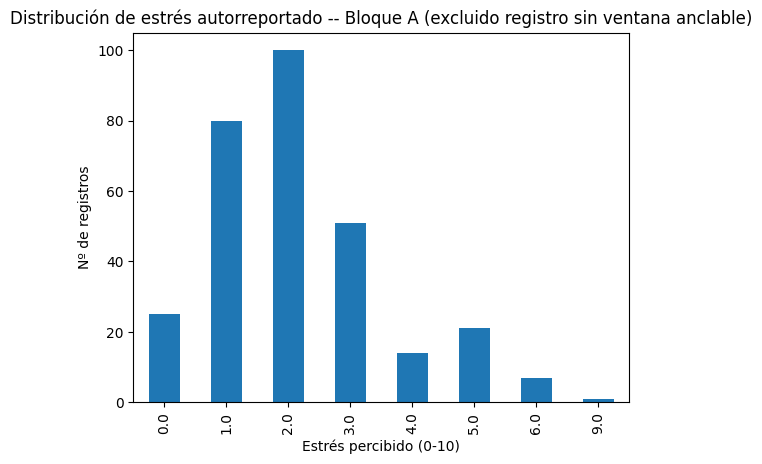

In [64]:
### Exclusión de registros con posible confusión fisiológica
df_ema_a = df_ema[(df_ema['block'] == 'A') & (df_ema['window_reliable'])]
# Excluidos por posible confusión fisiológica (infra-cobertura real en dosis omitida),
# no por duda sobre la calidad del dato -- ver discusión.

print(f"Bloque A usado para calibración: {len(df_ema_a)} de {len(df_ema[df_ema['block']=='A'])} registros")
print(df_ema_a['stress_score'].describe())


df_ema_a['stress_score'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Estrés percibido (0-10)')
plt.ylabel('Nº de registros')
plt.title('Distribución de estrés autorreportado -- Bloque A (excluido registro sin ventana anclable)')
plt.show()

Distribución de estrés autorreportado (299 registros válidos):
media 2,16, mediana 2, con una cola larga hasta 9.

Umbral elegido para "calma" (análogo a la condición Relajado de WESAD): `stress_score ≤ 1` —
estricto a propósito, para no colar días "normales" como si fueran de calma genuina.

In [65]:
# Cruce con los tramos candidatos de `steps=0` sostenido (v2: dosis+sueño+actividad excluidos)

ventanas_calma = df_ema_a[df_ema_a['stress_score'] <= 1]

def confirmado_por_ema(inicio, fin):
    return (
        (ventanas_calma['window_start'] <= inicio) & (ventanas_calma['window_end'] >= fin)
    ).any()

tramos_validos_v2['confirmado_calma_ema'] = tramos_validos_v2.apply(
    lambda r: confirmado_por_ema(r['inicio'], r['fin']), axis=1
)

n_total = len(tramos_validos_v2)
n_confirmados = tramos_validos_v2['confirmado_calma_ema'].sum()
print(f"{n_confirmados} de {n_total} tramos candidatos (steps=0 sostenido, v2) caen dentro de una ventana EMA con estrés <=1")
print(tramos_validos_v2[tramos_validos_v2['confirmado_calma_ema']].sort_values('inicio').to_string(index=False))

64 de 172 tramos candidatos (steps=0 sostenido, v2) caen dentro de una ventana EMA con estrés <=1
             inicio                 fin  duracion_min  delta_hr_medio  delta_hr_std  confirmado_calma_ema
2026-05-21 21:24:00 2026-05-21 21:59:00            36       -7.177863      4.712245                  True
2026-05-21 22:19:00 2026-05-21 23:10:00            52        0.319489      5.884359                  True
2026-05-21 23:13:00 2026-05-21 23:34:00            22       -2.966839      5.795753                  True
2026-05-22 11:06:00 2026-05-22 12:37:00            92      -10.387106      5.230893                  True
2026-05-22 20:51:00 2026-05-22 21:36:00            46       -6.181353      4.569653                  True
2026-05-22 22:27:00 2026-05-22 23:00:00            34       -1.680643      7.986018                  True
2026-05-22 23:29:00 2026-05-22 23:49:00            21       -3.511665      6.357639                  True
2026-05-25 21:31:00 2026-05-25 21:54:00            24 

Reutilizando los tramos ya identificados en 4.1.2 (v2: dosis+sueño+actividad y su recuperación
excluidos): de 172 tramos candidatos, **64 caen completos dentro de una ventana EMA con estrés ≤1**
— contención total, no solo solape parcial.

In [66]:
tramos_calma = tramos_validos_v2[tramos_validos_v2['confirmado_calma_ema']].copy()
tramos_calma['hora'] = tramos_calma['inicio'].dt.hour + tramos_calma['inicio'].dt.minute/60
print(tramos_calma[['inicio', 'hora', 'delta_hr_medio']].sort_values('hora').to_string(index=False))

             inicio      hora  delta_hr_medio
2026-06-30 10:22:00 10.366667        6.851347
2026-07-03 10:35:00 10.583333       -1.949445
2026-06-02 10:36:00 10.600000      -19.844265
2026-07-20 10:37:00 10.616667       -3.106187
2026-07-02 10:38:00 10.633333       -6.808116
2026-06-13 10:50:00 10.833333      -11.057019
2026-06-24 10:55:00 10.916667        0.534504
2026-07-17 10:56:00 10.933333      -16.070308
2026-06-20 10:57:00 10.950000       -5.154662
2026-06-08 11:01:00 11.016667       -3.263773
2026-05-22 11:06:00 11.100000      -10.387106
2026-07-02 11:13:00 11.216667       -1.159619
2026-07-13 11:17:00 11.283333       -2.548272
2026-06-12 11:21:00 11.350000      -14.757934
2026-06-13 11:29:00 11.483333       -9.488443
2026-05-28 11:41:00 11.683333      -20.059407
2026-06-24 11:42:00 11.700000       -5.468930
2026-06-23 12:13:00 12.216667      -14.477642
2026-05-28 12:16:00 12.266667       -9.360218
2026-06-08 12:19:00 12.316667        0.396847
2026-06-13 12:28:00 12.466667     

#### Media y sigma de referencia (calma EMA)

In [67]:
minutos_calma_ema = pd.concat([
    df_matriz.loc[r['inicio']:r['fin']] for _, r in tramos_calma.iterrows()
])

media_calma_ema = minutos_calma_ema['delta_hr'].mean()
sigma_calma_ema = minutos_calma_ema['delta_hr'].std()

print(f"Minutos totales: {len(minutos_calma_ema)}")
print(f"Media (calma EMA): {media_calma_ema:.3f} bpm")
print(f"Sigma (calma EMA): {sigma_calma_ema:.3f} bpm")

Minutos totales: 2373
Media (calma EMA): -3.923 bpm
Sigma (calma EMA): 10.008 bpm


#### Conclusión y decisión

**Comparación de las cuatro referencias calculadas:**

| Referencia | Media (bpm) | Sigma (bpm) | Minutos |
|---|---|---|---|
| 4.1.0 `sigma_global` (todo el tramo denso) | ~0 (por construcción del ajuste) | 11,638 | 85.903 |
| 4.1.1 `sigma_candidatos` (dosis+sueño excluidos) | -2,036 | 10,712 | 7.358 |
| 4.1.2 `sigma_candidatos_v2` (+ actividad y su recuperación) | -2,571 | 10,485 | 6.810 |
| 4.1.3 `sigma_calma_ema` (+ EMA ≤1) | -3,923 | 10,008 | 2.373 |

**Sobre la sigma:** converge de forma descendente a medida que se refina el criterio de calma
(11,638→10,712→10,485→10,008 bpm), aunque no de forma estrictamente monótona en el tamaño del
salto: la mayor caída ocurre entre 4.1.0 y 4.1.1 (excluir dosis/sueño, -0,93), el refinamiento por
actividad aporta un cambio menor (4.1.1→4.1.2, -0,23), pero el paso final por EMA vuelve a producir
una caída mayor (4.1.2→4.1.3, -0,48). No es una convergencia suave y decreciente en cada paso, pero
el rango final (~10,0-10,7 bpm) sigue siendo razonablemente estrecho, dando confianza en que este
orden de magnitud es una estimación estable del ruido fisiológico en reposo, no un artefacto del
criterio de filtrado exacto elegido.

**Sobre la media:** en vez de acercarse a cero a medida que se purifica la muestra de calma, se aleja
monótonamente (-2,036→-2,571→-3,923 bpm). Esto no es evidencia de que el filtrado esté fallando — al
contrario, es coherente con que el propio baseline circadiano (ajustado por MCMC sobre ventanas de 2
días que mezclan calma real, estrés real y actividad no siempre bien capturada por `d·Activity`)
queda sesgado al alza por esa contaminación, al no existir ningún término del modelo que corrija
explícitamente por estrés psicológico sin movimiento. Un baseline inflado predice, precisamente, que
la calma genuina se sitúe sistemáticamente por debajo de él — es decir, un residuo negativo, no
cercano a cero, es el resultado esperable, no una señal de que el criterio de calma sea inadecuado.

**Decisión:** se adopta `media_calma_ema`/`sigma_calma_ema` (4.1.3) como referencia de calibración de
`delta_hr_z_stressload` — combina el criterio fisiológico (exclusión de actividad y su cola de
recuperación) con el autorreporte (EMA), y su sigma cae dentro del rango ya estabilizado por las
referencias anteriores, mientras que su media es la más alejada de cero — coherente con ser, de las
cuatro, la muestra más depurada de calma genuina.

## 4.2. Cálculo de delta_hr_z_stressload

In [68]:
df_matriz['delta_hr_z_stressload'] = (df_matriz['delta_hr'] - media_calma_ema) / sigma_calma_ema

print(df_matriz['delta_hr_z_stressload'].describe())

count    53317.000000
mean         0.412239
std          1.162809
min         -5.400577
25%         -0.367766
50%          0.406239
75%          1.130438
max          8.317251
Name: delta_hr_z_stressload, dtype: float64


`delta_hr_z_stressload` queda calculado para los 53.317 minutos de vigilia con `delta_hr` válido,
calibrado contra `media_calma_ema`/`sigma_calma_ema` (4.1.3, sobre los 2.373 minutos de calma
confirmada por EMA). Su media y sigma globales no son exactamente 0/1 — es el comportamiento
esperado: la referencia de calibración se calcula solo sobre los minutos de calma confirmada, no
sobre todo el registro, así que el "cero" de esta feature representa calma, no el promedio del
tramo completo. La mayor parte del tiempo el valor está por encima de cero, reflejando que la
vigilia incluye actividad y estrés además de calma.

# 5. Replicación de features de WESAD (Camino B)

Este capítulo traduce `delta_hr` y `delta_hr_z_stressload` (Capítulo 4) al mismo
espacio de features que espera el clasificador de StressLoad(t), entrenado sobre
WESAD con el subconjunto "Camino B" — las 7 columnas transferibles a un wearable de
consumo (sin EDA/TEMP/HRV/ACC, que no proporciona un Xiaomi Watch S4 41mm): `HR_mean_norm`, sus rolling de 5 y 10 minutos (media y std), y sus
lags de 1 y 2 minutos.

La Sección 5.1 replica la lógica exacta de WESAD (rolling y lag posicionales, por
fila, no por tiempo transcurrido) — válida en WESAD porque sus sesiones no tienen
huecos, pero no necesariamente en el wearable real. La Sección 5.2 corrige esto
antes de dar las features por válidas para Risk(t).

## 5.1. Réplica fiel de Camino B

In [69]:
# Réplica fiel de WESAD (PASO 2): rolling posicional, por fila, no por tiempo transcurrido. 
# Válido tal cual en WESAD (sin huecos); en 5.2 se corrige para datos reales con huecos.
for ventana in [5, 10]:
    df_matriz[f'delta_hr_roll_mean_{ventana}m'] = df_matriz['delta_hr'].rolling(window=ventana, min_periods=1).mean()
    df_matriz[f'delta_hr_roll_std_{ventana}m'] = df_matriz['delta_hr'].rolling(window=ventana, min_periods=1).std().fillna(0)

print(df_matriz[['delta_hr_roll_mean_5m', 'delta_hr_roll_std_5m', 'delta_hr_roll_mean_10m', 'delta_hr_roll_std_10m']].describe())

       delta_hr_roll_mean_5m  delta_hr_roll_std_5m  delta_hr_roll_mean_10m  \
count           54836.000000          85903.000000            55776.000000   
mean                0.220617              2.683011                0.169784   
std                10.834298              2.978105               10.338672   
min               -57.972550              0.000000              -47.833106   
25%                -7.052380              0.000000               -6.776074   
50%                 0.095490              2.247703                0.139989   
75%                 6.825313              4.197254                6.503747   
max                69.760164             50.953798               66.641644   

       delta_hr_roll_std_10m  
count           85903.000000  
mean                3.343530  
std                 3.344745  
min                 0.000000  
25%                 0.000000  
50%                 3.180238  
75%                 5.251448  
max                35.995854  


Los rangos extremos observados (`delta_hr_roll_mean_5m` entre -58 y +70 bpm) y la pérdida de valores
no-nulos en la versión de media (54.836 de 85.903, 63,8%) son indicio de contaminación en los bordes
de vigilia/sueño: `.rolling(window=N)` opera sobre filas consecutivas de la tabla, sin distinguir si
esas filas son minutos reales consecutivos o si hay un tramo de sueño (o un hueco de datos) de por
medio. En WESAD esto no ocurre porque la sesión es continua y corta; en un registro real de varios
días es exactamente el problema que se corrige en 5.2.

In [70]:
for col in ['delta_hr_roll_mean_5m', 'delta_hr_roll_std_5m', 'delta_hr_roll_mean_10m', 'delta_hr_roll_std_10m']:
    minutos_calma_col = pd.concat([df_matriz.loc[r['inicio']:r['fin'], col] for _, r in tramos_calma.iterrows()])
    media_calma = minutos_calma_col.mean()
    sigma_calma = minutos_calma_col.std()
    df_matriz[f'{col}_norm'] = (df_matriz[col] - media_calma) / (sigma_calma + 1e-8)
    print(f"{col}: media_calma={media_calma:.3f}, sigma_calma={sigma_calma:.3f}")

delta_hr_roll_mean_5m: media_calma=-3.693, sigma_calma=9.336
delta_hr_roll_std_5m: media_calma=3.841, sigma_calma=2.158
delta_hr_roll_mean_10m: media_calma=-3.360, sigma_calma=9.069
delta_hr_roll_std_10m: media_calma=4.627, sigma_calma=2.254


Cada rolling tiene su propia referencia de calma, coherente entre sí y con la de `delta_hr`
(Capítulo 4, media_calma_ema=-3,923): las medias móviles de 5 y 10 minutos en calma son similares a
la de `delta_hr` sin suavizar (-3,694 y -3,361 respectivamente) — el suavizado no desplaza
sistemáticamente el nivel. Las stds móviles en calma no son cero (2,158 y 2,254 bpm): incluso en
reposo genuino hay variabilidad local de HR minuto a minuto, lo cual es fisiológicamente razonable y
da una referencia de "ruido basal en calma" contra la que comparar variabilidad elevada en los demás
minutos.

In [71]:
# Réplica fiel de WESAD (PASO 4): lag posicional, por fila. Mismo aviso que el
# rolling -- válido sin huecos, se corrige en 5.2 si hace falta.
for k in [1, 2]:
    df_matriz[f'delta_hr_z_stressload_lag_{k}m'] = df_matriz['delta_hr_z_stressload'].shift(k).fillna(0)

print(df_matriz[['delta_hr_z_stressload_lag_1m', 'delta_hr_z_stressload_lag_2m']].describe())

       delta_hr_z_stressload_lag_1m  delta_hr_z_stressload_lag_2m
count                  85903.000000                  85903.000000
mean                       0.255866                      0.255868
std                        0.937667                      0.937666
min                       -5.400577                     -5.400577
25%                        0.000000                      0.000000
50%                        0.000000                      0.000000
75%                        0.668711                      0.668711
max                        8.317251                      8.317251


Igual problema que el rolling, en otra forma: `fillna(0)` sustituye por 0 (el punto
de calma en `delta_hr_z_stressload`) cualquier lag que caiga en una fila sin dato
anterior válido -- en WESAD esto solo ocurre en el primer minuto de cada sesión
(caso raro); aquí, al haber huecos de sueño y de datos, ocurre en una fracción
mucho mayor de filas (la mediana (percentil 50) de ambos lags es exactamente 0,0, señal de que
los ceros por `fillna` pesan lo suficiente como para desplazar el propio percentil
50). Sustituir por 0 en esos casos asume implícitamente "sin dato previo = calma",
que no es una asunción neutra -- es otra manifestación del mismo problema de fondo
que 5.2 va a corregir, no un error nuevo.

## 5.2. Corrección gap-aware

La réplica fiel de 5.1 usa rolling y lag posicionales, tal como hace WESAD -- válido
allí porque sus sesiones son cortas y sin huecos. Sobre datos reales de varios días,
con sueño y con caídas de sensor, esa lógica produce dos problemas distintos, ambos
corregidos aquí:

1. **Cobertura insuficiente:** con `min_periods=1`, una "media de 5 minutos" puede
   estar calculada con un solo minuto real, sin ningún suavizado, y aun así
   presentarse como si fuera una media estable. Se exige un mínimo del 80% de
   minutos reales dentro de la ventana (umbral habitual en literatura de HRV/wearables
   para considerar una ventana suficientemente completa); si no se alcanza, la fila
   queda `NaN` en vez de una pseudo-media.

2. **Mezcla entre bloques de vigilia distintos:** un rolling o un lag puede combinar
   minutos de antes y después de una siesta (o de cualquier hueco), tratando dos
   episodios fisiológicos distintos como si fueran continuos. Se corrige agrupando
   por bloques contiguos de vigilia con dato válido, y calculando rolling/lag por
   separado dentro de cada bloque -- nunca a caballo entre dos.

A diferencia de WESAD, no se rellenan con 0 los casos sin suficiente dato (`std`
sin cobertura, o lag sin minuto anterior en el mismo bloque): 0 representaría
"sin variabilidad" o "nivel de calma", una afirmación fisiológica que no se puede
hacer solo porque falte el dato.

In [72]:

# Bloques contiguos de vigilia con delta_hr valido -- mismo criterio de agrupacion
# que ya usamos en 4.1.1 (groupby sobre cambios de condicion), para que el rolling
# nunca cruce sueno, siesta ni un hueco de sensor
es_vigilia_valida = (df_matriz['estado'] == 'Despierto') & df_matriz['delta_hr'].notna()
bloque_vigilia = (es_vigilia_valida != es_vigilia_valida.shift()).cumsum()
df_matriz['bloque_vigilia'] = bloque_vigilia.where(es_vigilia_valida)

COBERTURA_MINIMA = 0.8  # al menos 80% de minutos reales dentro de la ventana

for ventana in [5, 10]:
    min_periods = int(np.ceil(COBERTURA_MINIMA * ventana))
    df_matriz[f'delta_hr_roll_mean_{ventana}m_gapaware'] = (
        df_matriz.groupby('bloque_vigilia')['delta_hr']
        .transform(lambda x: x.rolling(window=ventana, min_periods=min_periods).mean())
    )
    df_matriz[f'delta_hr_roll_std_{ventana}m_gapaware'] = (
        df_matriz.groupby('bloque_vigilia')['delta_hr']
        .transform(lambda x: x.rolling(window=ventana, min_periods=min_periods).std())
    )
    # Nota: a diferencia de WESAD, NO se rellena con 0 la std sin suficiente cobertura --
    # NaN aqui significa "no hay suficiente dato real", no "sin variabilidad", que seria una afirmacion fisiologica falsa.

print(df_matriz[[
    'delta_hr_roll_mean_5m_gapaware', 'delta_hr_roll_std_5m_gapaware',
    'delta_hr_roll_mean_10m_gapaware', 'delta_hr_roll_std_10m_gapaware'
]].describe())

       delta_hr_roll_mean_5m_gapaware  delta_hr_roll_std_5m_gapaware  \
count                    51109.000000                   51109.000000   
mean                         0.080872                       4.104675   
std                         10.706967                       2.423530   
min                        -49.518072                       0.010028   
25%                         -7.111152                       2.426492   
50%                         -0.000500                       3.568122   
75%                          6.608490                       5.145406   
max                         69.760164                      27.550865   

       delta_hr_roll_mean_10m_gapaware  delta_hr_roll_std_10m_gapaware  
count                     48505.000000                    48505.000000  
mean                         -0.058903                        4.970135  
std                          10.143322                        2.411421  
min                         -42.327782                     

**Efecto de la corrección gap-aware:** el mínimo de `std` deja de ser 0 y el percentil 25 sube de
0,000 a 2,43 bpm -- desaparece el artefacto de ventanas de 1 punto reportadas como "sin
variabilidad". El recuento de filas válidas baja entre un 6,8% (ventana de 5m) y un 13,0% (ventana
de 10m), correspondiente a las ventanas con cobertura insuficiente que antes se calculaban
igualmente. El máximo se mantiene igual en ambas versiones (69,76 bpm en 5m; 66,64 bpm en 10m), lo
que indica que los valores extremos genuinos (episodios reales o posibles artefactos de sensor) no son un efecto del muestreo, y quedan para revisión aparte.

In [73]:
for k in [1, 2]:
    df_matriz[f'delta_hr_z_stressload_lag_{k}m_gapaware'] = (
        df_matriz.groupby('bloque_vigilia')['delta_hr_z_stressload'].shift(k)
    )
    # A diferencia de WESAD, NO se rellena con 0 -- NaN significa "no hay minuto
    # anterior real en este mismo bloque de vigilia", no "nivel de calma".

print(df_matriz[['delta_hr_z_stressload_lag_1m_gapaware', 'delta_hr_z_stressload_lag_2m_gapaware']].describe())

       delta_hr_z_stressload_lag_1m_gapaware  \
count                           52512.000000   
mean                                0.407958   
std                                 1.157863   
min                                -5.400577   
25%                                -0.368512   
50%                                 0.403628   
75%                                 1.125429   
max                                 8.317251   

       delta_hr_z_stressload_lag_2m_gapaware  
count                           51800.000000  
mean                                0.404091  
std                                 1.154170  
min                                -5.400577  
25%                                -0.369430  
50%                                 0.400648  
75%                                 1.122263  
max                                 8.317251  


Al eliminar el `fillna(0)`, la distribución de los lags gap-aware se parece mucho a la de
`delta_hr_z_stressload` sin desplazar (mediana 0,404/0,401 frente a 0,406) -- confirma que el
artefacto de la versión posicional (mediana exactamente en 0,0 por el relleno) ha desaparecido. El
coste es un 1,5-2,9% menos de filas válidas (52.512 y 51.800, frente a los 53.317 minutos de
`delta_hr_z_stressload`), correspondiente a los primeros minutos de cada bloque de vigilia, donde no
existe un minuto anterior real dentro del mismo bloque. 

In [74]:
# Normalizacion de los rolling gap-aware contra su propia referencia de calma
# (mismos minutos EMA-confirmados de 4.1/tramos_calma), replicando para estas
# columnas el mismo mecanismo que WESAD aplica a HR_mean_roll_mean_Xm

for col in ['delta_hr_roll_mean_5m_gapaware', 'delta_hr_roll_std_5m_gapaware',
            'delta_hr_roll_mean_10m_gapaware', 'delta_hr_roll_std_10m_gapaware']:
    minutos_calma_col = pd.concat([df_matriz.loc[r['inicio']:r['fin'], col] for _, r in tramos_calma.iterrows()])
    media_calma = minutos_calma_col.mean()
    sigma_calma = minutos_calma_col.std()
    df_matriz[f'{col}_norm'] = (df_matriz[col] - media_calma) / (sigma_calma + 1e-8)
    print(f"{col}: media_calma={media_calma:.3f}, sigma_calma={sigma_calma:.3f}, n_validos_calma={minutos_calma_col.notna().sum()}")

delta_hr_roll_mean_5m_gapaware: media_calma=-3.782, sigma_calma=9.305, n_validos_calma=2352
delta_hr_roll_std_5m_gapaware: media_calma=3.804, sigma_calma=2.093, n_validos_calma=2352
delta_hr_roll_mean_10m_gapaware: media_calma=-3.609, sigma_calma=9.002, n_validos_calma=2300
delta_hr_roll_std_10m_gapaware: media_calma=4.533, sigma_calma=2.117, n_validos_calma=2300


In [75]:
columnas_camino_b_nof1 = [
    'delta_hr_z_stressload',
    'delta_hr_roll_mean_5m_gapaware_norm',
    'delta_hr_roll_std_5m_gapaware_norm',
    'delta_hr_roll_mean_10m_gapaware_norm',
    'delta_hr_roll_std_10m_gapaware_norm',
    'delta_hr_z_stressload_lag_1m_gapaware',
    'delta_hr_z_stressload_lag_2m_gapaware',
]

print("Columnas presentes:", all(c in df_matriz.columns for c in columnas_camino_b_nof1))
print(f"\nMinutos totales en df_matriz: {len(df_matriz)}")
print(f"Minutos con las 7 columnas completas (sin ningun NaN): {df_matriz[columnas_camino_b_nof1].dropna().shape[0]}")
print()
print(df_matriz[columnas_camino_b_nof1].describe())

Columnas presentes: True

Minutos totales en df_matriz: 85903
Minutos con las 7 columnas completas (sin ningun NaN): 48505

       delta_hr_z_stressload  delta_hr_roll_mean_5m_gapaware_norm  \
count           53317.000000                         51109.000000   
mean                0.412239                             0.415151   
std                 1.162809                             1.150727   
min                -5.400577                            -4.915478   
25%                -0.367766                            -0.357809   
50%                 0.406239                             0.406406   
75%                 1.130438                             1.116705   
max                 8.317251                             7.903908   

       delta_hr_roll_std_5m_gapaware_norm  \
count                        51109.000000   
mean                             0.143541   
std                              1.157965   
min                             -1.812886   
25%                          

#### Conclusión

Se han replicado las 7 columnas de Camino B (WESAD) sobre el caso n-of-1: `delta_hr_z_stressload`
(equivalente a `HR_mean_norm`), sus rolling de 5 y 10 minutos (media y std, gap-aware y normalizados
contra la misma referencia de calma EMA del Capítulo 4), y sus lags de 1 y 2 minutos (respetando
bloques de vigilia, sin relleno artificial con 0).

De los 85.903 minutos totales del tramo denso, **48.505 (56,5%, ~88% de los minutos de vigilia)**
tienen las 7 columnas completas sin ningún NaN -- la ventana de 10 minutos es el cuello de botella,
al exigir más cobertura real que el resto.

El renombrado a los nombres exactos que espera el clasificador (`HR_mean_norm`, etc.) se hace en el
capítulo de aplicación del modelo, no aquí -- por las mismas razones ya discutidas en 4.2 (evitar
sugerir una equivalencia de cálculo que no existe).

## 5.3. Guardado del dataset

In [76]:
RUTA_PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df_matriz.to_parquet(RUTA_PROCESSED, engine="fastparquet")
print(f"Guardado: {RUTA_PROCESSED} ({len(df_matriz)} filas, {len(df_matriz.columns)} columnas)")

Guardado: ..\data\processed\MVA_n_of_1_extended.parquet (85903 filas, 40 columnas)


# Anexo
Se realiza un recuento de los días en que hay datos con estado "Despierto" en la franja nocturna 

In [77]:
import pandas as pd

umbrales = {
    "Más tarde de las 23:00": ("23:00", "23:59"),
    "Más tarde de las 00:00 (madrugada)": ("00:00", "00:59"),
    "Más tarde de la 01:00": ("01:00", "01:59"),
    "Más tarde de las 02:00": ("02:00", "02:59"),
}

total_dias = df_matriz.index.normalize().nunique()
print(f"Total de días en el tramo denso: {total_dias}\n")

for etiqueta, (h_ini, h_fin) in umbrales.items():
    franja = df_matriz.between_time(h_ini, h_fin)
    dias_despierta = franja[franja["estado"] == "Despierto"].index.normalize().unique()
    print(f"{etiqueta}: {len(dias_despierta)} día(s)")
    for dia in sorted(dias_despierta):
        print("   -", dia.strftime("%Y-%m-%d"))
    print()

Total de días en el tramo denso: 61

Más tarde de las 23:00: 53 día(s)
   - 2026-05-21
   - 2026-05-22
   - 2026-05-23
   - 2026-05-24
   - 2026-05-26
   - 2026-05-27
   - 2026-05-28
   - 2026-05-29
   - 2026-05-30
   - 2026-05-31
   - 2026-06-01
   - 2026-06-02
   - 2026-06-03
   - 2026-06-04
   - 2026-06-05
   - 2026-06-06
   - 2026-06-07
   - 2026-06-08
   - 2026-06-09
   - 2026-06-10
   - 2026-06-11
   - 2026-06-12
   - 2026-06-13
   - 2026-06-14
   - 2026-06-15
   - 2026-06-17
   - 2026-06-18
   - 2026-06-19
   - 2026-06-20
   - 2026-06-21
   - 2026-06-22
   - 2026-06-23
   - 2026-06-24
   - 2026-06-25
   - 2026-06-26
   - 2026-06-27
   - 2026-06-28
   - 2026-06-29
   - 2026-06-30
   - 2026-07-02
   - 2026-07-03
   - 2026-07-04
   - 2026-07-05
   - 2026-07-06
   - 2026-07-08
   - 2026-07-10
   - 2026-07-12
   - 2026-07-14
   - 2026-07-15
   - 2026-07-16
   - 2026-07-17
   - 2026-07-18
   - 2026-07-19

Más tarde de las 00:00 (madrugada): 18 día(s)
   - 2026-05-22
   - 2026-05-23
  

In [78]:
ventana_evento = df_matriz.loc["2026-06-07 00:45":"2026-06-07 01:20", ["estado", "steps", "heart_rate_bpm"]]
print(ventana_evento.to_string())

                             estado  steps  heart_rate_bpm
datetime                                                  
2026-06-07 00:45:00       Despierto    0.0           110.0
2026-06-07 00:46:00       Despierto    0.0           103.0
2026-06-07 00:47:00       Despierto    0.0           106.0
2026-06-07 00:48:00       Despierto    0.0           108.0
2026-06-07 00:49:00       Despierto   12.0           105.0
2026-06-07 00:50:00       Despierto    0.0           108.0
2026-06-07 00:51:00       Despierto   16.0           108.0
2026-06-07 00:52:00       Despierto    0.0           103.0
2026-06-07 00:53:00       Despierto    9.0           104.0
2026-06-07 00:54:00       Despierto    0.0            90.0
2026-06-07 00:55:00       Despierto    0.0            82.0
2026-06-07 00:56:00       Despierto    0.0            82.0
2026-06-07 00:57:00       Despierto    0.0            82.0
2026-06-07 00:58:00  Dormido(noche)    0.0            87.0
2026-06-07 00:59:00  Dormido(noche)    0.0            90